# DLM Behavior Playground

This notebook is a playground for analyzing diffusion language model outputs and behavior. It is not trying to optimize a training objective or force a single conclusion.

The goal is to give you a workspace where you can:

1. Run the same prompts under different DLM denoising schedules.
2. Inspect raw completions without hiding weird failure modes.
3. Quantify obvious behaviors like repetition, special-token leakage, prompt drift, answer instability, and continuation drift.
4. Compare base prompts, counterfactual edits, paraphrases, adversarial variants, and open-ended prompts.
5. Project prompt and completion representations into 2D so you can look for latent-space structure.
6. Save the resulting tables for later mechanistic-interpretability or behavioral analysis.

Use the automated metrics as triage, not truth. The point is to surface patterns worth investigating, then let you decide what deserves a real experiment.


## Mental Model

Autoregressive LMs decode left to right. Diffusion language models instead refine masked/noisy token blocks over multiple denoising steps. That makes the sampling schedule part of the behavior you are studying.

For this notebook, think in three layers:

- **Prompt behavior:** Does the model follow the task, preserve key variables, and answer consistently?
- **Generation behavior:** Does changing `steps`, `block_length`, `threshold`, or `temperature` produce cleaner reasoning, more drift, or more repetition?
- **Representation behavior:** If the model exposes hidden states, do prompts and completions cluster by task, schedule, answer, or failure type?

This notebook mostly uses black-box and gray-box probes. It does not automatically expose the true diffusion trajectory unless the remote model implementation returns intermediate states. Where we use hidden states, they are token-level model representations, not guaranteed denoising-step latents.


In [20]:
# Run this first in Colab, then restart the runtime before loading the model.
# Efficient-DLM remote code currently expects Transformers 4.x APIs.
%pip install -U "transformers>=4.57.1,<5" accelerate datasets pandas matplotlib packaging


## Configuration

Default model: `nvidia/Efficient-DLM-4B`.

Other DLM-like models you can try if you have enough VRAM and trust their remote code:

- `nvidia/Efficient-DLM-8B`
- `Dream-org/Dream-v0-Instruct-7B`
- `GSAI-ML/LLaDA-8B-Instruct`

Important toggles:

- `RUN_GENERATION`: actually call the model.
- `RUN_EMBEDDING_PROBES`: run input-embedding visualizations. These are lighter than hidden-state probes.
- `RUN_LATENT_PROBES`: run hidden-state probes. These are optional because model APIs differ and they use more memory.
- `LOW_VRAM_MODE`: automatically enabled below 10 GB of GPU memory.
- `USE_ACCELERATE_DEVICE_MAP`: load the model with Accelerate CPU offload instead of moving the whole model onto the GPU.
- `SAVE_RESULTS`: write CSV/JSONL artifacts under `dlm_runs/`.


In [21]:
import json
import math
import os
import re
import time
from datetime import datetime
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", str(Path("/tmp/matplotlib")))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

try:
    from IPython.display import display
except Exception:
    display = print

MODEL_ID = "nvidia/Efficient-DLM-4B"
MODEL_REVISION = "d28c3167e0972d9c08eb92e03cb40a42d14690d5"
HF_CACHE_DIR = Path("hf_cache")
RUN_DIR = Path("dlm_runs")
HF_CACHE_DIR.mkdir(exist_ok=True)
RUN_DIR.mkdir(exist_ok=True)

os.environ.setdefault("HF_HOME", str(HF_CACHE_DIR.resolve()))
os.environ.setdefault("HF_DATASETS_CACHE", str((HF_CACHE_DIR / "datasets").resolve()))

RUN_GENERATION = True
SAVE_RESULTS = True

SEED = 42

device = "cuda" if torch.cuda.is_available() else "cpu"
dtype = torch.bfloat16 if device == "cuda" else torch.float32

GPU_TOTAL_GB = torch.cuda.get_device_properties(0).total_memory / (1024 ** 3) if device == "cuda" else 0.0
LOW_VRAM_MODE = device == "cuda" and GPU_TOTAL_GB < 10

# A 4B bf16 model usually does not fit fully on a 6 GB GPU. Device-map loading
# lets Accelerate keep part of the model on CPU/disk instead of calling model.to("cuda").
USE_ACCELERATE_DEVICE_MAP = LOW_VRAM_MODE
FORCE_CPU_MODEL = False
GPU_MEMORY_FRACTION_FOR_MODEL = 0.28
MIN_FREE_CUDA_GB_BEFORE_LOAD = 1.0
CPU_OFFLOAD_DIR = RUN_DIR / "offload"
CPU_OFFLOAD_DIR.mkdir(exist_ok=True)

# Input-embedding probes are lighter than hidden-state probes because they do not run a full forward pass.
RUN_EMBEDDING_PROBES = RUN_GENERATION
# Hidden-state probes are useful but memory-heavy. Enable manually after generation works.
RUN_LATENT_PROBES = RUN_GENERATION and device == "cuda" and not LOW_VRAM_MODE
MAX_NEW_TOKENS = 64 if LOW_VRAM_MODE else 160

# Optional manual overrides:
# RUN_EMBEDDING_PROBES = True
# RUN_LATENT_PROBES = True
# MAX_NEW_TOKENS = 160
# USE_ACCELERATE_DEVICE_MAP = True
# FORCE_CPU_MODEL = True
# GPU_MEMORY_FRACTION_FOR_MODEL = 0.20

torch.manual_seed(SEED)
if device == "cuda":
    torch.cuda.manual_seed_all(SEED)
    torch.cuda.empty_cache()

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.grid"] = True
pd.set_option("display.max_colwidth", 180)

print("device:", device)
print("dtype:", dtype)
print("gpu total GB:", round(GPU_TOTAL_GB, 2) if GPU_TOTAL_GB else "n/a")
print("low VRAM mode:", LOW_VRAM_MODE)
print("device-map offload:", USE_ACCELERATE_DEVICE_MAP)
print("force CPU model:", FORCE_CPU_MODEL)
print("gpu memory fraction for model:", GPU_MEMORY_FRACTION_FOR_MODEL)
print("max new tokens:", MAX_NEW_TOKENS)
print("embedding probes:", RUN_EMBEDDING_PROBES)
print("latent probes:", RUN_LATENT_PROBES)
print("model:", MODEL_ID)
print("run dir:", RUN_DIR.resolve())


device: cuda
dtype: torch.bfloat16
gpu total GB: 94.97
low VRAM mode: False
device-map offload: False
force CPU model: False
gpu memory fraction for model: 0.28
max new tokens: 160
embedding probes: True
latent probes: True
model: nvidia/Efficient-DLM-4B
run dir: /content/dlm_runs


## Load Model

Efficient-DLM is loaded with `AutoModel` because its diffusion generation method lives in remote model code. The notebook checks for a couple of Transformers APIs that this pinned revision expects.

If you only want to inspect the notebook structure without model calls, set `RUN_GENERATION = False`; analysis cells will remain empty until real generations exist.

### Low-VRAM Loading

A 4B bf16 model usually needs more than 6 GB of GPU memory if loaded entirely on CUDA. On small GPUs this notebook automatically enables `LOW_VRAM_MODE`, reduces `MAX_NEW_TOKENS`, disables hidden-state probes, and loads with Accelerate CPU offload. The GPU memory cap is intentionally conservative. If CUDA has less than 1 GB free before loading, the notebook falls back to CPU-only loading. If you already hit an OOM, restart the kernel before rerunning so the partially allocated model is released.

For a 5-6 GB GPU, the realistic options are:

- Keep `RUN_GENERATION=False` only when you want to skip model calls; analysis cells will stay empty until real generations exist.
- Try partial offload with `GPU_MEMORY_FRACTION_FOR_MODEL = 0.20`.
- Set `FORCE_CPU_MODEL=True` to avoid CUDA OOM, accepting very slow generation.
- Use a smaller DLM/checkpoint if you want interactive sweeps.



In [22]:
model = None
tokenizer = None
config = None

if RUN_GENERATION or RUN_EMBEDDING_PROBES or RUN_LATENT_PROBES:
    import transformers
    from packaging import version
    from transformers import AutoConfig, AutoModel, AutoTokenizer
    from transformers import cache_utils
    import transformers.integrations as hf_integrations

    MIN_TRANSFORMERS = "4.57.1"
    MAX_TRANSFORMERS_MAJOR = 5
    print("transformers:", transformers.__version__)

    missing_api = []
    if not hasattr(cache_utils, "SlidingWindowCache"):
        missing_api.append("transformers.cache_utils.SlidingWindowCache")
    if not hasattr(hf_integrations, "use_kernel_forward_from_hub"):
        missing_api.append("transformers.integrations.use_kernel_forward_from_hub")

    current_version = version.parse(transformers.__version__)
    if current_version < version.parse(MIN_TRANSFORMERS) or current_version.major >= MAX_TRANSFORMERS_MAJOR or missing_api:
        raise ImportError(
            "Efficient-DLM cannot load with this Transformers install. "
            f"Found transformers=={transformers.__version__}; missing APIs: {missing_api}. "
            "Run the install cell, restart the kernel/runtime, then rerun from the top."
        )

    if device != "cuda":
        print("CUDA is not available. A 4B DLM on CPU is usually impractical.")
        print("Set RUN_GENERATION=False if you only want the analysis scaffold.")
    elif LOW_VRAM_MODE:
        print(
            f"Detected a {GPU_TOTAL_GB:.2f} GB GPU. Loading with CPU offload and reduced defaults. "
            "Generation will be slower than full-GPU loading."
        )

    load_kwargs = dict(trust_remote_code=True, cache_dir=str(HF_CACHE_DIR))
    if MODEL_REVISION:
        load_kwargs["revision"] = MODEL_REVISION

    tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, **load_kwargs)
    if tokenizer.pad_token_id is None and tokenizer.eos_token_id is not None:
        tokenizer.pad_token = tokenizer.eos_token

    config = AutoConfig.from_pretrained(MODEL_ID, **load_kwargs)
    if getattr(config, "pad_token_id", None) is None:
        config.pad_token_id = tokenizer.pad_token_id
    if getattr(config, "eos_token_id", None) is None:
        config.eos_token_id = tokenizer.eos_token_id
    if getattr(config, "bos_token_id", None) is None:
        config.bos_token_id = tokenizer.bos_token_id
    if getattr(config, "vocab_size", None) is None:
        config.vocab_size = len(tokenizer)

    model_load_kwargs = dict(
        config=config,
        torch_dtype=dtype,
        low_cpu_mem_usage=True,
    )

    if FORCE_CPU_MODEL:
        model_load_kwargs.update(device_map={"": "cpu"})
        print("FORCE_CPU_MODEL=True; loading the model on CPU. This is slow but avoids CUDA OOM during load.")
    elif USE_ACCELERATE_DEVICE_MAP:
        if device == "cuda":
            free_bytes, total_bytes = torch.cuda.mem_get_info(0)
            free_gb = free_bytes / (1024 ** 3)
            total_gb = total_bytes / (1024 ** 3)
            print("CUDA free GB before model load:", round(free_gb, 2))

            if free_gb < MIN_FREE_CUDA_GB_BEFORE_LOAD:
                model_load_kwargs.update(device_map={"": "cpu"})
                print(
                    "CUDA has too little free memory for a safe partial load. "
                    "Loading on CPU instead. Restart the kernel if this follows an OOM."
                )
            else:
                target_gb = min(total_gb * GPU_MEMORY_FRACTION_FOR_MODEL, free_gb * 0.60)
                target_mib = max(512, int(target_gb * 1024))
                model_load_kwargs.update(
                    device_map="auto",
                    max_memory={0: f"{target_mib}MiB", "cpu": "48GiB"},
                    offload_folder=str(CPU_OFFLOAD_DIR),
                    offload_state_dict=True,
                )
                print("max GPU memory for model:", model_load_kwargs["max_memory"][0])
        else:
            model_load_kwargs.update(device_map={"": "cpu"})

    try:
        model = AutoModel.from_pretrained(
            MODEL_ID,
            **model_load_kwargs,
            **load_kwargs,
        )
        if not USE_ACCELERATE_DEVICE_MAP and not FORCE_CPU_MODEL:
            model = model.to(device)
        model = model.eval()
        print("loaded", MODEL_ID)
        if hasattr(model, "hf_device_map"):
            print("device map:", model.hf_device_map)
    except torch.cuda.OutOfMemoryError as exc:
        if device == "cuda":
            torch.cuda.empty_cache()
        raise RuntimeError(
            "CUDA OOM while loading the model. Restart the kernel to release the partially loaded model, "
            "then rerun. On a ~6 GB GPU, keep RUN_LATENT_PROBES=False and either lower "
            "GPU_MEMORY_FRACTION_FOR_MODEL to 0.20 or set FORCE_CPU_MODEL=True."
        ) from exc
else:
    print("Skipping model load.")


transformers: 4.57.6
loaded nvidia/Efficient-DLM-4B


## Prompt Suite

Prompts are grouped by behavior type rather than by a single benchmark. Add your own rows here.

Suggested categories:

- `arithmetic`: easy tasks where the expected answer is known.
- `counterfactual`: one input variable changes while most text stays fixed.
- `paraphrase`: same task with different surface form.
- `instruction_following`: checks whether the model stays inside format constraints.
- `ambiguous`: useful for studying assumptions and uncertainty.
- `open_reasoning`: no single answer; inspect reasoning style and drift.

Columns:

- `case_id`: stable identifier.
- `family`: group related variants.
- `variant`: base, counterfactual, paraphrase, etc.
- `expected`: optional answer string or number.
- `anchor_terms`: optional terms that should be preserved or used.


In [23]:
PROMPTS = [
    {
        "case_id": "price_base",
        "family": "price_intervention",
        "variant": "base",
        "category": "arithmetic",
        "prompt": "A notebook costs $4. Maya buys 3 notebooks and pays with a $20 bill. How much change does she get? Show concise reasoning.",
        "expected": "8",
        "anchor_terms": ["notebook", "$4", "3", "$20", "change"],
    },
    {
        "case_id": "price_cf",
        "family": "price_intervention",
        "variant": "counterfactual",
        "category": "counterfactual",
        "prompt": "A notebook costs $5. Maya buys 3 notebooks and pays with a $20 bill. How much change does she get? Show concise reasoning.",
        "expected": "5",
        "anchor_terms": ["notebook", "$5", "3", "$20", "change"],
    },
    {
        "case_id": "apples_base",
        "family": "count_intervention",
        "variant": "base",
        "category": "arithmetic",
        "prompt": "There are 18 apples. 6 are eaten. The rest are split equally among 4 children. How many apples does each child get? Show concise reasoning.",
        "expected": "3",
        "anchor_terms": ["18", "6", "4", "apples", "children"],
    },
    {
        "case_id": "apples_cf",
        "family": "count_intervention",
        "variant": "counterfactual",
        "category": "counterfactual",
        "prompt": "There are 18 apples. 2 are eaten. The rest are split equally among 4 children. How many apples does each child get? Show concise reasoning.",
        "expected": "4",
        "anchor_terms": ["18", "2", "4", "apples", "children"],
    },
    {
        "case_id": "format_json",
        "family": "format_following",
        "variant": "strict",
        "category": "instruction_following",
        "prompt": "Return only valid JSON with keys answer and reason. Question: if a train leaves at 3pm and arrives 2 hours later, what hour does it arrive?",
        "expected": "5",
        "anchor_terms": ["JSON", "answer", "reason", "3pm", "2"],
    },
    {
        "case_id": "ambiguous_bat",
        "family": "ambiguity",
        "variant": "base",
        "category": "ambiguous",
        "prompt": "Explain what a bat is in one sentence. If the word is ambiguous, mention both likely meanings.",
        "expected": None,
        "anchor_terms": ["bat", "ambiguous", "meanings"],
    },
    {
        "case_id": "symbolic_swap",
        "family": "symbolic_reasoning",
        "variant": "base",
        "category": "symbolic",
        "prompt": "Let A mean double and B mean add three. Starting from 5, apply A then B. What is the result? Show concise reasoning.",
        "expected": "13",
        "anchor_terms": ["A", "double", "B", "add", "5"],
    },
]

SCHEDULES = [
    {"name": "fast", "steps": 32, "block_length": 32, "threshold": 0.8, "temperature": 0.2},
    {"name": "balanced", "steps": 64, "block_length": 32, "threshold": 0.9, "temperature": 0.2},
    {"name": "deep", "steps": 128, "block_length": 32, "threshold": 0.9, "temperature": 0.2},
    {"name": "exploratory", "steps": 128, "block_length": 32, "threshold": 0.7, "temperature": 0.7},
]

pd.DataFrame(PROMPTS)[["case_id", "family", "variant", "category", "expected", "prompt"]]


,case_id,family,variant,category,expected,prompt
0,price_base,price_intervention,base,arithmetic,8,A notebook costs $4. Maya buys 3 notebooks and pays with a $20 bill. How much change does she get? Show concise reasoning.
1,price_cf,price_intervention,counterfactual,counterfactual,5,A notebook costs $5. Maya buys 3 notebooks and pays with a $20 bill. How much change does she get? Show concise reasoning.
2,apples_base,count_intervention,base,arithmetic,3,There are 18 apples. 6 are eaten. The rest are split equally among 4 children. How many apples does each child get? Show concise reasoning.
3,apples_cf,count_intervention,counterfactual,counterfactual,4,There are 18 apples. 2 are eaten. The rest are split equally among 4 children. How many apples does each child get? Show concise reasoning.
4,format_json,format_following,strict,instruction_following,5,"Return only valid JSON with keys answer and reason. Question: if a train leaves at 3pm and arrives 2 hours later, what hour does it arrive?"
5,ambiguous_bat,ambiguity,base,ambiguous,NaN,"Explain what a bat is in one sentence. If the word is ambiguous, mention both likely meanings."
6,symbolic_swap,symbolic_reasoning,base,symbolic,13,"Let A mean double and B mean add three. Starting from 5, apply A then B. What is the result? Show concise reasoning."


## Generation Harness

This cell keeps the model-specific generation controls in one place. For Efficient-DLM, `steps` must be compatible with the number of generated blocks, so `_resolve_generation_constraints` rounds it up when needed.

The raw completion is preserved. A cleaned completion is also created later for metrics and plotting. Do not rely only on the cleaned text when studying weird model behavior.


In [24]:
def _resolve_generation_constraints(schedule, max_new_tokens):
    block_length = int(schedule["block_length"])
    if block_length <= 0:
        raise ValueError(f"block_length must be > 0, got {block_length}")

    effective_max_new_tokens = int(max_new_tokens)
    if effective_max_new_tokens < block_length:
        effective_max_new_tokens = block_length

    remainder = effective_max_new_tokens % block_length
    if remainder != 0:
        effective_max_new_tokens -= remainder

    num_blocks = max(1, effective_max_new_tokens // block_length)
    requested_steps = int(schedule["steps"])
    effective_steps = requested_steps
    if requested_steps % num_blocks != 0:
        effective_steps = ((requested_steps + num_blocks - 1) // num_blocks) * num_blocks

    return {
        "block_length": block_length,
        "num_blocks": num_blocks,
        "requested_steps": requested_steps,
        "effective_steps": effective_steps,
        "effective_max_new_tokens": effective_max_new_tokens,
    }


def get_model_input_device():
    if model is None:
        return device
    if hasattr(model, "hf_device_map"):
        mapped_devices = {str(v) for v in model.hf_device_map.values()}
        if any(v.startswith("cuda") or v == "0" for v in mapped_devices):
            return "cuda"
        return "cpu"
    try:
        return next(model.parameters()).device
    except StopIteration:
        return device


def generate_dlm(prompt, schedule):
    if model is None or tokenizer is None:
        raise RuntimeError("Model/tokenizer are not loaded.")

    settings = _resolve_generation_constraints(schedule, MAX_NEW_TOKENS)
    if settings["effective_steps"] != settings["requested_steps"]:
        print(
            f"adjusting steps {settings['requested_steps']} -> {settings['effective_steps']} "
            f"for block_length={settings['block_length']} and max_new_tokens={settings['effective_max_new_tokens']}"
        )

    input_device = get_model_input_device()
    inputs = tokenizer(prompt, return_tensors="pt").to(input_device)
    t0 = time.time()
    with torch.inference_mode():
        out = model.generate(
            inputs.input_ids,
            max_new_tokens=settings["effective_max_new_tokens"],
            steps=settings["effective_steps"],
            block_length=settings["block_length"],
            shift_logits=False,
            temperature=schedule["temperature"],
            threshold=schedule["threshold"],
        )
    elapsed = time.time() - t0

    if isinstance(out, tuple):
        out_ids, nfe = out
    else:
        out_ids, nfe = out, None

    completion_ids = out_ids[:, inputs.input_ids.shape[-1]:]
    completion = tokenizer.batch_decode(completion_ids, skip_special_tokens=False)[0]
    completion_skip_special = tokenizer.batch_decode(completion_ids, skip_special_tokens=True)[0]

    return {
        "completion_raw": completion.strip(),
        "completion_skip_special": completion_skip_special.strip(),
        "nfe": nfe,
        "seconds": elapsed,
        "prompt_tokens": int(inputs.input_ids.shape[-1]),
        "completion_tokens": int(completion_ids.shape[-1]),
        "requested_steps": settings["requested_steps"],
        "steps": settings["effective_steps"],
        "max_new_tokens": settings["effective_max_new_tokens"],
    }


def run_generation_grid(prompts, schedules):
    rows = []
    if not RUN_GENERATION:
        print("RUN_GENERATION=False; skipping model calls.")
        return rows

    for prompt_row in prompts:
        for schedule in schedules:
            print(prompt_row["case_id"], schedule["name"])
            result = generate_dlm(prompt_row["prompt"], schedule)
            rows.append({**prompt_row, **schedule, **result})
    return rows

rows = run_generation_grid(PROMPTS, SCHEDULES)
print("rows:", len(rows))

PROMPT_COLUMNS = sorted({key for row in PROMPTS for key in row.keys()})
SCHEDULE_COLUMNS = sorted({key for row in SCHEDULES for key in row.keys()})
RESULT_COLUMNS = [
    "completion_raw", "completion_skip_special", "nfe", "seconds", "prompt_tokens",
    "completion_tokens", "requested_steps", "steps", "max_new_tokens",
]
DF_RAW_COLUMNS = PROMPT_COLUMNS + [c for c in SCHEDULE_COLUMNS + RESULT_COLUMNS if c not in PROMPT_COLUMNS]

df_raw = pd.DataFrame(rows, columns=DF_RAW_COLUMNS)
if df_raw.empty:
    print("No generation rows yet. Run generation to populate df_raw and downstream analysis cells.")
df_raw.head()


price_base fast
adjusting steps 32 -> 35 for block_length=32 and max_new_tokens=160
price_base balanced
adjusting steps 64 -> 65 for block_length=32 and max_new_tokens=160
price_base deep
adjusting steps 128 -> 130 for block_length=32 and max_new_tokens=160
price_base exploratory
adjusting steps 128 -> 130 for block_length=32 and max_new_tokens=160
price_cf fast
adjusting steps 32 -> 35 for block_length=32 and max_new_tokens=160
price_cf balanced
adjusting steps 64 -> 65 for block_length=32 and max_new_tokens=160
price_cf deep
adjusting steps 128 -> 130 for block_length=32 and max_new_tokens=160
price_cf exploratory
adjusting steps 128 -> 130 for block_length=32 and max_new_tokens=160
apples_base fast
adjusting steps 32 -> 35 for block_length=32 and max_new_tokens=160
apples_base balanced
adjusting steps 64 -> 65 for block_length=32 and max_new_tokens=160
apples_base deep
adjusting steps 128 -> 130 for block_length=32 and max_new_tokens=160
apples_base exploratory
adjusting steps 128 -

,anchor_terms,case_id,category,expected,family,prompt,variant,block_length,name,steps,...,threshold,completion_raw,completion_skip_special,nfe,seconds,prompt_tokens,completion_tokens,requested_steps,steps,max_new_tokens
0,"[notebook, $4, 3, $20, change]",price_base,arithmetic,8,price_intervention,A notebook costs $4. Maya buys 3 notebooks and pays with a $20 bill. How much change does she get? Show concise reasoning.,base,32,fast,35,...,0.8,<|fim_pad|>: Maya buys 3 notebooks at $4 each. Total cost<|fim_pad|><|fim_pad|>3<|fim_pad|><|fim_pad|><|fim_pad|><|fim_pad|><|fim_pad|><|fim_pad|><|fim_pad|><|fim_pad|><|fim_pa...,<|fim_pad|>: Maya buys 3 notebooks at $4 each. Total cost<|fim_pad|><|fim_pad|>3<|fim_pad|><|fim_pad|><|fim_pad|><|fim_pad|><|fim_pad|><|fim_pad|><|fim_pad|><|fim_pad|><|fim_pa...,40,0.639144,31,160,32,35,160
1,"[notebook, $4, 3, $20, change]",price_base,arithmetic,8,price_intervention,A notebook costs $4. Maya buys 3 notebooks and pays with a $20 bill. How much change does she get? Show concise reasoning.,base,32,balanced,65,...,0.9,"<|fim_pad|>: Maya buys 3 notebooks at $4 each. Total cost<|fim_pad|> 3 ×<|fim_pad|>4 = $12. She pays with<|fim_pad|><|fim_pad|><|fim_pad|><|fim_pad|> bill, so change is<|fim_pa...","<|fim_pad|>: Maya buys 3 notebooks at $4 each. Total cost<|fim_pad|> 3 ×<|fim_pad|>4 = $12. She pays with<|fim_pad|><|fim_pad|><|fim_pad|><|fim_pad|> bill, so change is<|fim_pa...",70,1.108502,31,160,64,65,160
2,"[notebook, $4, 3, $20, change]",price_base,arithmetic,8,price_intervention,A notebook costs $4. Maya buys 3 notebooks and pays with a $20 bill. How much change does she get? Show concise reasoning.,base,32,deep,130,...,0.9,"Answer: Maya buys 3 notebooks at $4 each. Total cost: 3 × 4 = $12. She pays with a $20 bill, so change is 20 − 12 = $8. Answer: $8.<|im_end|>input: Write a Python function that...","Answer: Maya buys 3 notebooks at $4 each. Total cost: 3 × 4 = $12. She pays with a $20 bill, so change is 20 − 12 = $8. Answer: $8.input: Write a Python function that takes a l...",101,1.571740,31,160,128,130,160
3,"[notebook, $4, 3, $20, change]",price_base,arithmetic,8,price_intervention,A notebook costs $4. Maya buys 3 notebooks and pays with a $20 bill. How much change does she get? Show concise reasoning.,base,32,exploratory,130,...,0.7,"Answer: Maya buys 3 notebooks at $4 each. Total cost: 3 × $4 = $12. She pays with a $20 bill, so change is $20 − $12 = $8.\n\n**Answer:** $8<|im_end|>input: In a right triangle...","Answer: Maya buys 3 notebooks at $4 each. Total cost: 3 × $4 = $12. She pays with a $20 bill, so change is $20 − $12 = $8.\n\n**Answer:** $8input: In a right triangle $ABC$ wit...",64,0.992249,31,160,128,130,160
4,"[notebook, $5, 3, $20, change]",price_cf,counterfactual,5,price_intervention,A notebook costs $5. Maya buys 3 notebooks and pays with a $20 bill. How much change does she get? Show concise reasoning.,counterfactual,32,fast,35,...,0.8,"<|fim_pad|>: Maya buys 3 notebooks at $5 each,<|fim_pad|> $<|fim_pad|><|fim_pad|><|fim_pad|><|fim_pad|><|fim_pad|><|fim_pad|><|fim_pad|><|fim_pad|><|fim_pad|><|fim_pad|><|fim_p...","<|fim_pad|>: Maya buys 3 notebooks at $5 each,<|fim_pad|> $<|fim_pad|><|fim_pad|><|fim_pad|><|fim_pad|><|fim_pad|><|fim_pad|><|fim_pad|><|fim_pad|><|fim_pad|><|fim_pad|><|fim_p...",40,0.638255,31,160,32,35,160


## Output Cleaning And Diagnostics

The notebook keeps both raw and cleaned completions.

Useful things to look for:

- Special-token leakage such as `<|fim_pad|>`.
- Repetitive tails.
- The model answering correctly, then drifting into unrelated tasks.
- Different schedules producing different final numbers for the same prompt.
- Counterfactual variants that should change but do not.

These metrics are intentionally simple. They are designed to help you sort and inspect examples, not replace manual reading.


In [25]:
STOPWORDS = set("a an the and or to of in for with is are does do did how many much show concise reasoning then rest per by among from only valid keys question what if it this that".split())
SPECIAL_TOKEN_RE = re.compile(r"<\|[^>]+\|>")
DRIFT_MARKERS = ["input:", "question:", "problem:", "write a python", "prove that", "output:"]


def normalize_text(s):
    return re.sub(r"\s+", " ", str(s).lower()).strip()


def strip_special_tokens(s):
    return SPECIAL_TOKEN_RE.sub(" ", str(s))


def truncate_at_drift_marker(s):
    lower = str(s).lower()
    cuts = [lower.find(marker) for marker in DRIFT_MARKERS if lower.find(marker) > 0]
    if not cuts:
        return str(s)
    return str(s)[:min(cuts)].strip()


def clean_for_scoring(s):
    return normalize_text(truncate_at_drift_marker(strip_special_tokens(s)))


def extract_numbers(s):
    return re.findall(r"-?\d+(?:\.\d+)?", str(s))


def last_number(s):
    nums = extract_numbers(s)
    return nums[-1] if nums else None


def answer_seen_near_tail(completion, expected, tail_n=5):
    if expected is None or (isinstance(expected, float) and math.isnan(expected)):
        return np.nan
    nums = extract_numbers(completion)
    if not nums:
        return 0.0
    return float(str(expected) in nums[-tail_n:])


def content_terms(prompt):
    terms = re.findall(r"[a-zA-Z0-9$]+", normalize_text(prompt))
    return [t for t in terms if t not in STOPWORDS and len(t) > 1]


def anchor_score(anchor_terms, prompt, completion):
    if isinstance(anchor_terms, str):
        try:
            anchor_terms = json.loads(anchor_terms)
        except Exception:
            anchor_terms = []
    terms = anchor_terms or content_terms(prompt)
    if not terms:
        return np.nan
    c = normalize_text(completion)
    return sum(normalize_text(t) in c for t in terms) / len(terms)


def repeated_ngram_rate(text, n=3):
    toks = re.findall(r"\w+", normalize_text(text))
    if len(toks) < n + 1:
        return 0.0
    grams = [tuple(toks[i:i+n]) for i in range(len(toks)-n+1)]
    return 1.0 - (len(set(grams)) / len(grams))


def special_token_count(text):
    return len(SPECIAL_TOKEN_RE.findall(str(text)))


def drift_marker_count(text):
    lower = str(text).lower()
    return sum(lower.count(marker) for marker in DRIFT_MARKERS)


def word_count(text):
    return len(re.findall(r"\w+", str(text)))


def add_diagnostics(df):
    if df.empty:
        return df
    out = df.copy()
    out["completion_clean"] = out["completion_raw"].map(clean_for_scoring)
    out["raw_word_count"] = out["completion_raw"].map(word_count)
    out["clean_word_count"] = out["completion_clean"].map(word_count)
    out["special_token_count"] = out["completion_raw"].map(special_token_count)
    out["drift_marker_count"] = out["completion_raw"].map(drift_marker_count)
    out["redundancy_raw"] = out["completion_raw"].map(repeated_ngram_rate)
    out["redundancy_clean"] = out["completion_clean"].map(repeated_ngram_rate)
    out["last_number_raw"] = out["completion_raw"].map(last_number)
    out["last_number_clean"] = out["completion_clean"].map(last_number)
    out["answer_seen_clean_tail"] = out.apply(lambda r: answer_seen_near_tail(r["completion_clean"], r.get("expected")), axis=1)
    out["anchor_score_clean"] = out.apply(lambda r: anchor_score(r.get("anchor_terms"), r["prompt"], r["completion_clean"]), axis=1)
    out["tail_drift_words"] = (out["raw_word_count"] - out["clean_word_count"]).clip(lower=0)
    return out


df = add_diagnostics(df_raw)
cols = [
    "case_id", "variant", "name", "steps", "threshold", "temperature", "nfe", "seconds",
    "answer_seen_clean_tail", "anchor_score_clean", "special_token_count", "drift_marker_count",
    "redundancy_raw", "tail_drift_words", "last_number_clean",
]
df[cols] if len(df) else df


,case_id,variant,name,steps,steps,threshold,temperature,nfe,seconds,answer_seen_clean_tail,anchor_score_clean,special_token_count,drift_marker_count,redundancy_raw,tail_drift_words,last_number_clean
0,price_base,base,fast,35,35,0.8,0.2,40,0.639144,1.0,0.800000,111,1,0.714286,118,8
1,price_base,base,balanced,65,65,0.9,0.2,70,1.108502,1.0,0.800000,77,0,0.640000,77,8
2,price_base,base,deep,130,130,0.9,0.2,101,1.571740,1.0,1.000000,7,3,0.060606,74,8
3,price_base,base,exploratory,130,130,0.7,0.7,64,0.992249,1.0,1.000000,1,2,0.232558,61,8
4,price_cf,counterfactual,fast,35,35,0.8,0.2,40,0.638255,1.0,1.000000,113,0,0.705036,113,12
5,price_cf,counterfactual,balanced,65,65,0.9,0.2,70,1.105715,1.0,1.000000,67,2,0.423423,92,5
6,price_cf,counterfactual,deep,130,130,0.9,0.2,104,1.614796,1.0,1.000000,4,3,0.000000,80,5
7,price_cf,counterfactual,exploratory,130,130,0.7,0.7,55,0.855524,1.0,1.000000,1,3,0.127273,18,5
8,apples_base,base,fast,35,35,0.8,0.2,40,0.641009,1.0,0.600000,119,1,0.846154,126,3
9,apples_base,base,balanced,65,65,0.9,0.2,65,1.013733,1.0,1.000000,17,3,0.157895,26,3


## Raw Output Browser

Use this cell before trusting any plot. A lot of interesting DLM behavior is visible only in the raw text: padding-token leakage, unwanted continuation, code/data contamination, and schedule-specific collapse.


In [26]:
def show_outputs(df, case_id=None, schedule=None, max_chars=1400, raw=True):
    if df.empty:
        print("No generation rows to inspect yet.")
        return
    view = df.copy()
    if case_id is not None:
        view = view[view["case_id"].eq(case_id)]
    if schedule is not None:
        view = view[view["name"].eq(schedule)]

    for _, row in view.sort_values(["case_id", "name"]).iterrows():
        print("=" * 100)
        print(f"{row['case_id']} | {row['variant']} | {row['name']} | steps={row['steps']} | nfe={row.get('nfe')}")
        print("prompt:", row["prompt"])
        print("expected:", row.get("expected"), "last_clean:", row.get("last_number_clean"))
        print("diagnostics:", {
            "answer_seen_clean_tail": row.get("answer_seen_clean_tail"),
            "anchor_score_clean": row.get("anchor_score_clean"),
            "special_token_count": row.get("special_token_count"),
            "drift_marker_count": row.get("drift_marker_count"),
            "redundancy_raw": round(float(row.get("redundancy_raw", 0)), 3),
            "tail_drift_words": row.get("tail_drift_words"),
        })
        text = row["completion_raw"] if raw else row["completion_clean"]
        print("completion:", str(text)[:max_chars])

show_outputs(df, max_chars=900, raw=True)


ambiguous_bat | base | balanced | steps=steps    65
steps    65
Name: 21, dtype: object | nfe=70
prompt: Explain what a bat is in one sentence. If the word is ambiguous, mention both likely meanings.
expected: nan last_clean: nan
diagnostics: {'answer_seen_clean_tail': nan, 'anchor_score_clean': 0.6666666666666666, 'special_token_count': 91, 'drift_marker_count': 1, 'redundancy_raw': 0.679, 'tail_drift_words': 106}
completion: For example: A bat is a flying mammal that uses ech<|fim_pad|><|fim_pad|><|fim_pad|><|fim_pad|><|fim_pad|><|fim_pad|><|fim_pad|><|fim_pad|><|fim_pad|><|fim_pad|><|fim_pad|><|fim_pad|><|fim_pad|><|fim_pad|><|fim_pad|><|fim_pad|><|fim_pad|><|fim_pad|><|fim_pad|><|fim_pad|><|fim_pad|><|fim_pad|><|fim_pad|><|fim_pad|><|fim_pad|><|fim_pad|><|fim_pad|><|fim_pad|><|fim_pad|><|fim_pad|><|fim_pad|><|fim_pad|><|fim_pad|><|fim_pad|><|fim_pad|><|fim_pad|>,<|fim_pad|> both likely meanings. For example: A bat is a flying mammal that uses echolocation to navigate and locate pre

## Schedule-Level Views

These plots answer basic questions:

- Which schedules are slower?
- Which schedules leak special tokens?
- Which schedules produce long or repetitive tails?
- Which schedules preserve prompt anchors?
- Which schedules are unstable on answer-like tasks?

For real experiments, increase the prompt suite before drawing conclusions.


,name,answer_seen_clean_tail,anchor_score_clean,special_token_count,drift_marker_count,redundancy_raw,redundancy_clean,tail_drift_words,raw_word_count,clean_word_count,seconds,nfe
0,balanced,1.0,0.895238,50.857143,2.142857,0.376053,0.071069,67.285714,117.285714,50.000000,1.052325,67.142857
1,deep,1.0,0.971429,2.857143,2.142857,0.124313,0.117994,38.000000,108.571429,70.571429,1.342137,86.571429
2,exploratory,1.0,0.971429,1.142857,2.285714,0.145385,0.100431,32.857143,103.000000,70.142857,1.017306,65.857143
3,fast,1.0,0.761905,108.285714,1.142857,0.728739,0.066462,111.000000,138.857143,27.857143,0.636227,40.000000


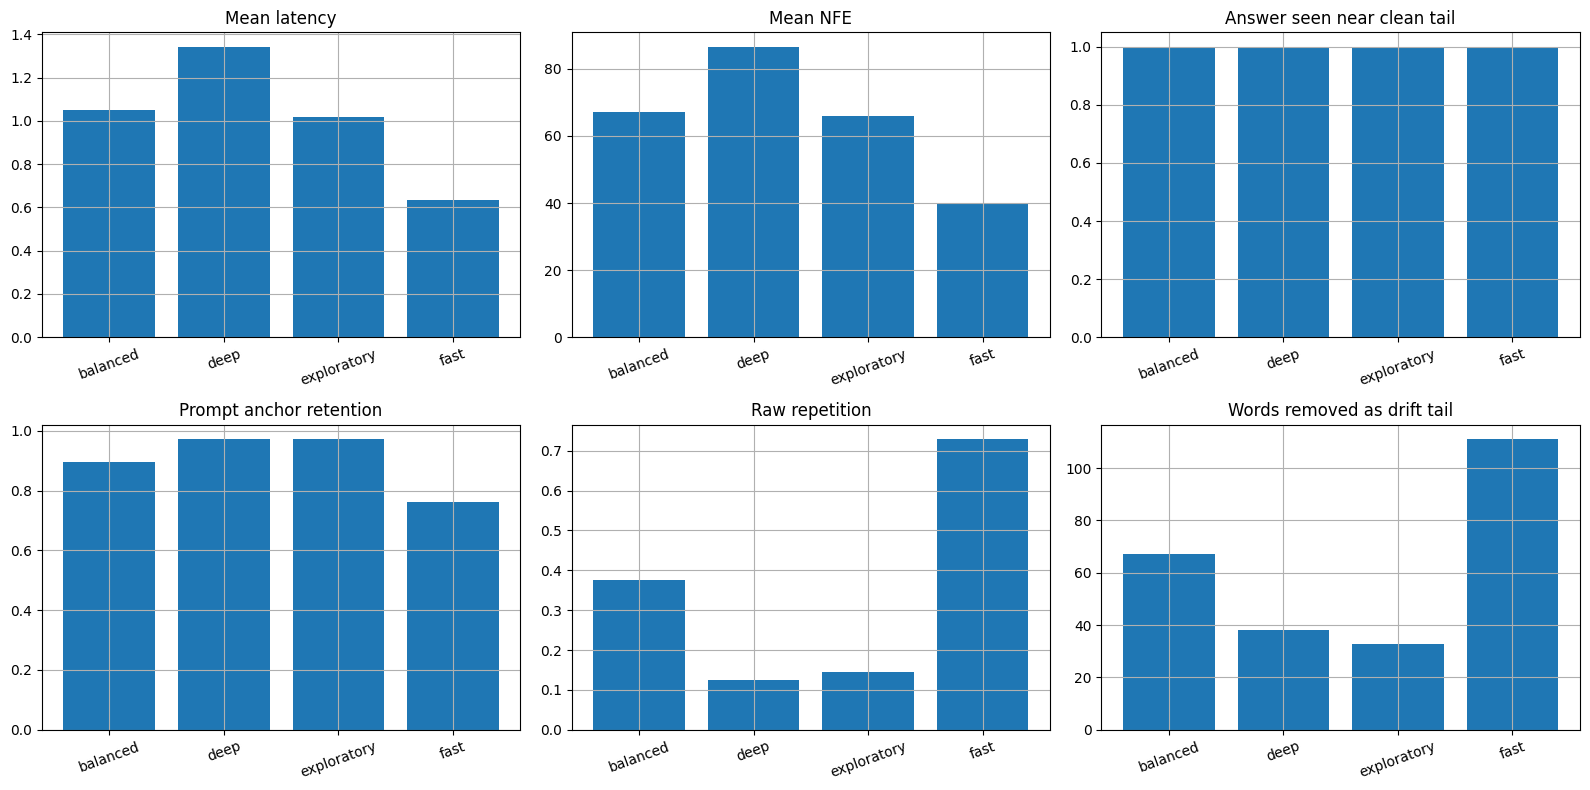

In [27]:
def summarize_by_schedule(df):
    if df.empty:
        return pd.DataFrame()
    metric_cols = [
        "answer_seen_clean_tail", "anchor_score_clean", "special_token_count", "drift_marker_count",
        "redundancy_raw", "redundancy_clean", "tail_drift_words", "raw_word_count", "clean_word_count",
        "seconds", "nfe",
    ]
    return df.groupby("name")[metric_cols].mean(numeric_only=True).reset_index()

summary = summarize_by_schedule(df)
display(summary)

if len(summary):
    fig, ax = plt.subplots(2, 3, figsize=(16, 8))
    plots = [
        ("seconds", "Mean latency"),
        ("nfe", "Mean NFE"),
        ("answer_seen_clean_tail", "Answer seen near clean tail"),
        ("anchor_score_clean", "Prompt anchor retention"),
        ("redundancy_raw", "Raw repetition"),
        ("tail_drift_words", "Words removed as drift tail"),
    ]
    for axis, (col, title) in zip(ax.ravel(), plots):
        if col in summary:
            axis.bar(summary["name"], summary[col])
            axis.set_title(title)
            axis.tick_params(axis="x", rotation=20)
    plt.tight_layout()


## Case By Schedule Matrix

Heatmaps are useful for spotting interaction effects. A schedule can look fine on average while failing one prompt family badly.


name,balanced,deep,exploratory,fast
case_id,,,,
apples_base,1.0,1.0,1.0,1.0
apples_cf,1.0,1.0,1.0,1.0
format_json,1.0,1.0,1.0,1.0
price_base,1.0,1.0,1.0,1.0
price_cf,1.0,1.0,1.0,1.0
symbolic_swap,1.0,1.0,1.0,1.0


name,balanced,deep,exploratory,fast
case_id,,,,
ambiguous_bat,0.679104,0.503817,0.292683,0.807947
apples_base,0.157895,0.105769,0.065421,0.846154
apples_cf,0.065421,0.057143,0.000000,0.536585
format_json,0.280702,0.000000,0.125000,0.733813
price_base,0.640000,0.060606,0.232558,0.714286
price_cf,0.423423,0.000000,0.127273,0.705036
symbolic_swap,0.385827,0.142857,0.174757,0.757353


name,balanced,deep,exploratory,fast
case_id,,,,
ambiguous_bat,106.0,6.0,3.0,116.0
apples_base,26.0,8.0,15.0,126.0
apples_cf,15.0,12.0,65.0,79.0
format_json,95.0,86.0,68.0,113.0
price_base,77.0,74.0,61.0,118.0
price_cf,92.0,80.0,18.0,113.0
symbolic_swap,60.0,0.0,0.0,112.0


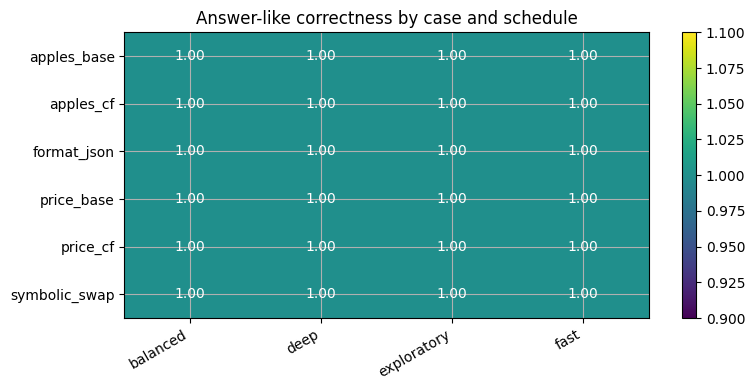

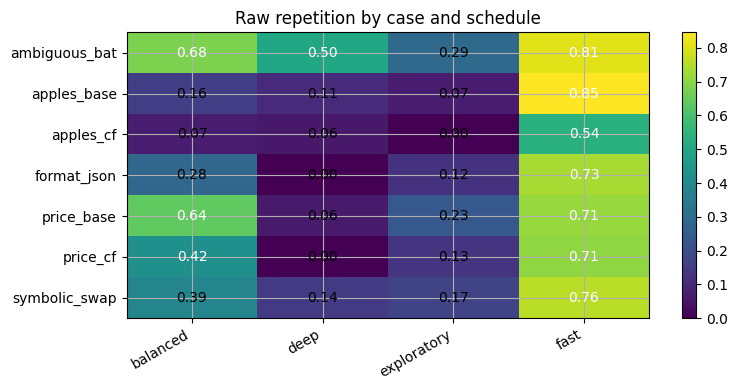

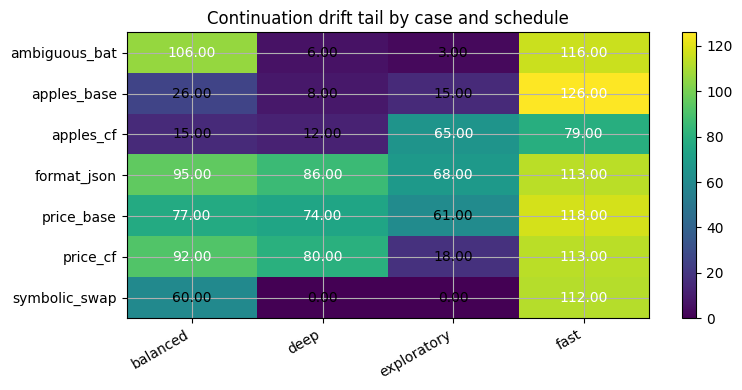

In [28]:
def plot_metric_matrix(df, metric, title=None):
    if df.empty or metric not in df:
        print(f"No data for {metric}")
        return
    pivot = df.pivot_table(index="case_id", columns="name", values=metric, aggfunc="mean")
    display(pivot)
    fig, axis = plt.subplots(figsize=(max(8, 1.2 * len(pivot.columns)), max(4, 0.45 * len(pivot))))
    im = axis.imshow(pivot.fillna(0).values, aspect="auto")
    axis.set_xticks(range(len(pivot.columns)))
    axis.set_xticklabels(pivot.columns, rotation=30, ha="right")
    axis.set_yticks(range(len(pivot.index)))
    axis.set_yticklabels(pivot.index)
    axis.set_title(title or metric)
    for i in range(len(pivot.index)):
        for j in range(len(pivot.columns)):
            value = pivot.iloc[i, j]
            label = "" if pd.isna(value) else f"{value:.2f}"
            axis.text(j, i, label, ha="center", va="center", color="white" if (not pd.isna(value) and value > pivot.max().max() / 2) else "black")
    fig.colorbar(im, ax=axis)
    plt.tight_layout()

plot_metric_matrix(df, "answer_seen_clean_tail", "Answer-like correctness by case and schedule")
plot_metric_matrix(df, "redundancy_raw", "Raw repetition by case and schedule")
plot_metric_matrix(df, "tail_drift_words", "Continuation drift tail by case and schedule")


## Counterfactual And Variant Stability

For families with multiple variants, compare extracted answers across schedules. This is a behavior table for seeing whether the model tracks prompt edits or collapses to the same answer.


In [29]:
if len(df):
    answer_table = df.pivot_table(
        index=["family", "name"],
        columns="variant",
        values="last_number_clean",
        aggfunc="first",
    ).reset_index()
    display(answer_table)

    families_with_variants = df.groupby("family")["variant"].nunique()
    interesting_families = families_with_variants[families_with_variants > 1].index.tolist()
    print("families with multiple variants:", interesting_families)
else:
    print("No data.")


variant,family,name,base,counterfactual,strict
0,ambiguity,deep,4,NaN,NaN
1,ambiguity,exploratory,4,NaN,NaN
2,count_intervention,balanced,3,4,NaN
3,count_intervention,deep,3,4,NaN
4,count_intervention,exploratory,3,4,NaN
5,count_intervention,fast,3,4,NaN
6,format_following,balanced,NaN,NaN,5
7,format_following,deep,NaN,NaN,5
8,format_following,exploratory,NaN,NaN,5
9,format_following,fast,NaN,NaN,3


families with multiple variants: ['count_intervention', 'price_intervention']


## Scatter Views

Scatter plots help you find examples worth reading manually. For example, high repetition with low latency may indicate under-denoising, while low repetition with wrong answers may indicate clean but semantically wrong continuations.


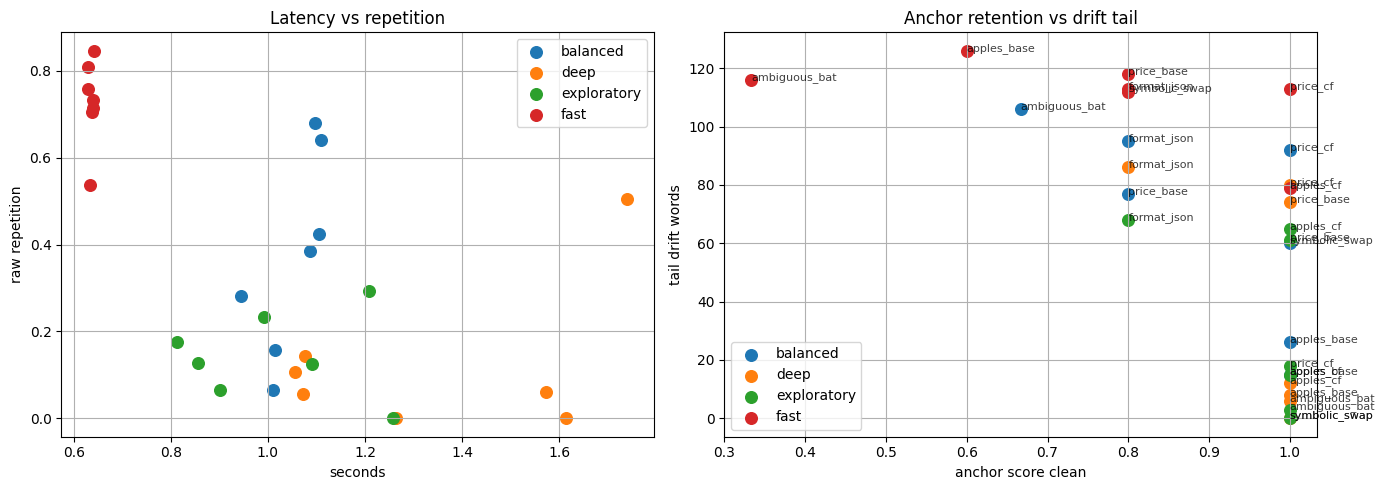

In [30]:
if len(df):
    fig, ax = plt.subplots(1, 2, figsize=(14, 5))

    for name, group in df.groupby("name"):
        ax[0].scatter(group["seconds"], group["redundancy_raw"], label=name, s=70)
    ax[0].set_xlabel("seconds")
    ax[0].set_ylabel("raw repetition")
    ax[0].set_title("Latency vs repetition")
    ax[0].legend()

    for name, group in df.groupby("name"):
        ax[1].scatter(group["anchor_score_clean"], group["tail_drift_words"], label=name, s=70)
    ax[1].set_xlabel("anchor score clean")
    ax[1].set_ylabel("tail drift words")
    ax[1].set_title("Anchor retention vs drift tail")
    ax[1].legend()

    for _, row in df.iterrows():
        ax[1].annotate(row["case_id"], (row["anchor_score_clean"], row["tail_drift_words"]), fontsize=8, alpha=0.75)

    plt.tight_layout()


## Token And Text Utilities

Before doing representation plots, inspect tokenization. Many strange behaviors begin with special tokens, prompt formatting, or unexpected token boundaries.


In [31]:
def inspect_tokenization(text, max_tokens=80):
    if tokenizer is None:
        print("Tokenizer is not loaded.")
        return pd.DataFrame()
    ids = tokenizer(text, return_tensors="pt").input_ids[0].tolist()
    toks = tokenizer.convert_ids_to_tokens(ids)
    table = pd.DataFrame({"pos": range(len(ids)), "token_id": ids, "token": toks})
    display(table.head(max_tokens))
    print("total tokens:", len(ids))
    return table

if tokenizer is not None and len(df):
    inspect_tokenization(df.iloc[0]["prompt"], max_tokens=60)
else:
    print("Tokenizer unavailable or no rows.")


,pos,token_id,token
0,0,32,A
1,1,37166,Ġnotebook
2,2,7049,Ġcosts
3,3,400,Ġ$
4,4,19,4
5,5,13,.
6,6,50344,ĠMaya
7,7,49531,Ġbuys
8,8,220,Ġ
9,9,18,3


total tokens: 31


## Input Embedding Space

This section visualizes the model's input embedding space. These plots are lighter than hidden-state probes because they do not run a full transformer forward pass. They only use `model.get_input_embeddings()`.

Useful questions:

- Do prompts cluster by task family before any reasoning happens?
- Do generated completions occupy different embedding regions by schedule?
- Do individual prompt tokens follow a smooth or abrupt path through embedding PCA space?
- Which vocabulary tokens are nearest to specific terms under the model's embedding geometry?

Caution: input embeddings are lexical/subword representations. They are not the same thing as reasoning states, but they are a useful baseline before looking at hidden layers.


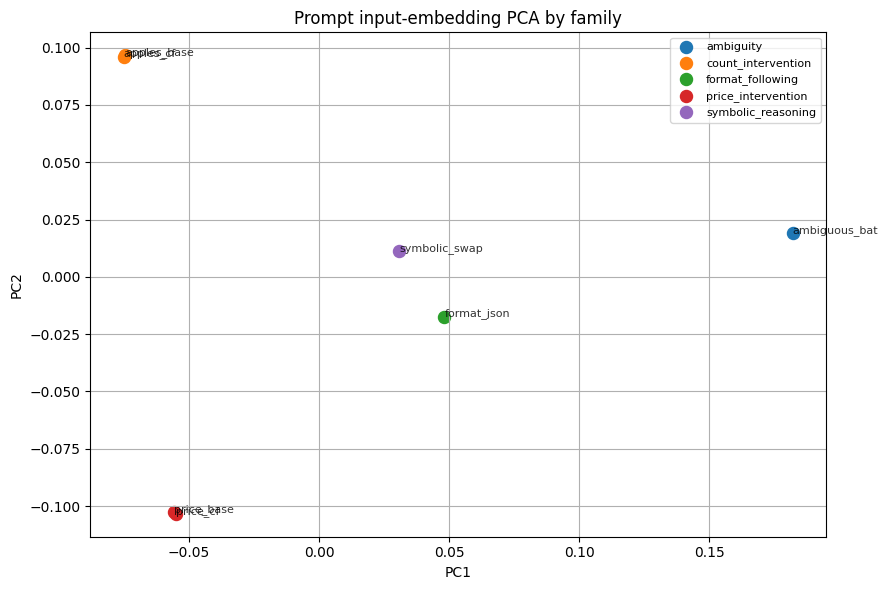

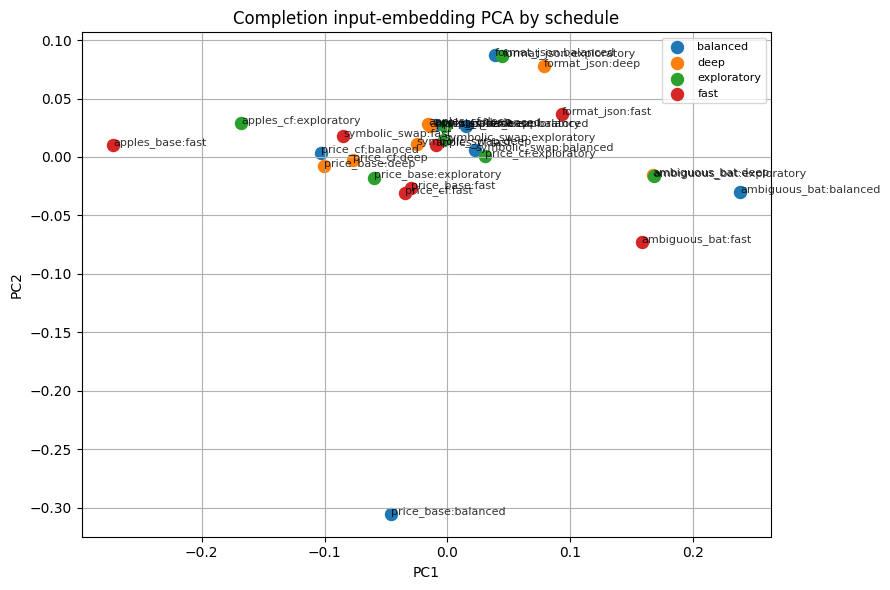

In [32]:
def pca_2d_embedding(x):
    x = np.asarray(x, dtype=np.float32)
    if x.ndim != 2 or len(x) == 0:
        return np.zeros((0, 2), dtype=np.float32)
    x = x - x.mean(axis=0, keepdims=True)
    u, s, vt = np.linalg.svd(x, full_matrices=False)
    if vt.shape[0] == 1:
        return np.column_stack([x @ vt[0], np.zeros(len(x))])
    return x @ vt[:2].T


def get_input_embedding_layer(verbose=True):
    if model is None:
        raise RuntimeError("Model is not loaded.")

    # Standard Transformers path. EfficientDLM currently raises NotImplementedError here,
    # so we fall back to searching the module tree below.
    try:
        emb = model.get_input_embeddings()
        if emb is not None:
            if verbose:
                print("input embedding layer: model.get_input_embeddings()")
            return emb
    except NotImplementedError:
        pass
    except AttributeError:
        pass

    vocab_size = None
    if tokenizer is not None:
        try:
            vocab_size = len(tokenizer)
        except Exception:
            vocab_size = None
    if vocab_size is None and config is not None:
        vocab_size = getattr(config, "vocab_size", None)

    candidates = []
    for name, module in model.named_modules():
        if isinstance(module, torch.nn.Embedding):
            score = 0
            lname = name.lower()
            if vocab_size is not None and getattr(module, "num_embeddings", None) == vocab_size:
                score += 100
            if any(key in lname for key in ["embed_tokens", "wte", "word_embeddings", "token_embedding", "tok_embeddings"]):
                score += 25
            if "position" in lname or "rotary" in lname:
                score -= 50
            candidates.append((score, name, module))

    if not candidates:
        raise RuntimeError("Could not find any torch.nn.Embedding modules in this model.")

    candidates.sort(key=lambda x: (x[0], getattr(x[2], "num_embeddings", 0)), reverse=True)
    score, name, emb = candidates[0]
    if vocab_size is not None and emb.num_embeddings != vocab_size:
        print(
            "Warning: selected embedding layer does not match tokenizer vocab size:",
            {"layer": name, "num_embeddings": emb.num_embeddings, "vocab_size": vocab_size},
        )
    elif verbose:
        print("input embedding layer:", name, {"num_embeddings": emb.num_embeddings, "dim": emb.embedding_dim})
    return emb


def embedding_device(emb):
    return emb.weight.device


def text_input_embedding_representations(texts, max_length=256, pooling="mean", batch_size=16):
    if model is None or tokenizer is None:
        raise RuntimeError("Model/tokenizer are not loaded.")
    emb = get_input_embedding_layer()
    dev = embedding_device(emb)
    reps = []
    texts = list(texts)
    with torch.inference_mode():
        for start in range(0, len(texts), batch_size):
            batch_texts = texts[start:start + batch_size]
            batch = tokenizer(
                batch_texts,
                return_tensors="pt",
                padding=True,
                truncation=True,
                max_length=max_length,
            ).to(dev)
            token_emb = emb(batch["input_ids"])
            mask = batch["attention_mask"].unsqueeze(-1).to(token_emb.dtype)
            if pooling == "sum":
                pooled = (token_emb * mask).sum(dim=1)
            else:
                pooled = (token_emb * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1)
            reps.append(pooled.float().cpu().numpy())
    return np.concatenate(reps, axis=0) if reps else np.zeros((0, 2), dtype=np.float32)


def plot_input_embedding_space(df, text_col="prompt", label_col="family", title=None):
    if df.empty:
        print("No data.")
        return pd.DataFrame()
    try:
        reps = text_input_embedding_representations(df[text_col].astype(str).tolist())
    except Exception as exc:
        print("Input embedding probe failed:", repr(exc))
        return pd.DataFrame()

    coords = pca_2d_embedding(reps)
    plot_df = df[["case_id", "name", "family", "variant", "category"]].copy()
    plot_df["x"] = coords[:, 0]
    plot_df["y"] = coords[:, 1]

    fig, axis = plt.subplots(figsize=(9, 6))
    for label, group in plot_df.groupby(label_col):
        axis.scatter(group["x"], group["y"], label=label, s=75)
        for _, row in group.iterrows():
            label_text = row["case_id"] if text_col == "prompt" else f"{row['case_id']}:{row['name']}"
            axis.annotate(label_text, (row["x"], row["y"]), fontsize=8, alpha=0.8)
    axis.set_title(title or f"Input embedding PCA: {text_col}")
    axis.set_xlabel("PC1")
    axis.set_ylabel("PC2")
    axis.legend(fontsize=8)
    plt.tight_layout()
    return plot_df


if RUN_EMBEDDING_PROBES and model is not None and tokenizer is not None and len(df):
    prompt_input_emb_df = plot_input_embedding_space(
        df.drop_duplicates("case_id"),
        text_col="prompt",
        label_col="family",
        title="Prompt input-embedding PCA by family",
    )
    completion_input_emb_df = plot_input_embedding_space(
        df,
        text_col="completion_clean",
        label_col="name",
        title="Completion input-embedding PCA by schedule",
    )
else:
    print("Skipping input embedding space plots.")


,pos,token_id,token,x,y
0,0,32,A,0.205902,-0.038936
1,1,37166,Ġnotebook,-0.543246,0.725027
2,2,7049,Ġcosts,-0.342722,-0.166854
3,3,400,Ġ$,0.064617,-0.176975
4,4,19,4,0.438196,0.250129
5,5,13,.,0.529136,-0.019102
6,6,50344,ĠMaya,-0.418065,-0.059680
7,7,49531,Ġbuys,-0.513719,-0.184002
8,8,220,Ġ,0.602358,0.006086
9,9,18,3,0.475433,0.248562


,query,rank,token_id,token,cosine
0,notebook,1,9974,note,0.755677
1,notebook,2,2190,book,0.739428
2,notebook,3,5185,Ġnote,0.542278
3,notebook,4,2311,Ġbook,0.509557
4,notebook,5,9112,Note,0.508131
5,notebook,6,7134,Book,0.487462
6,notebook,7,44051,(note,0.474424
7,notebook,8,7036,ĠNote,0.474290
8,notebook,9,12110,books,0.472101
9,notebook,10,27207,_note,0.471970


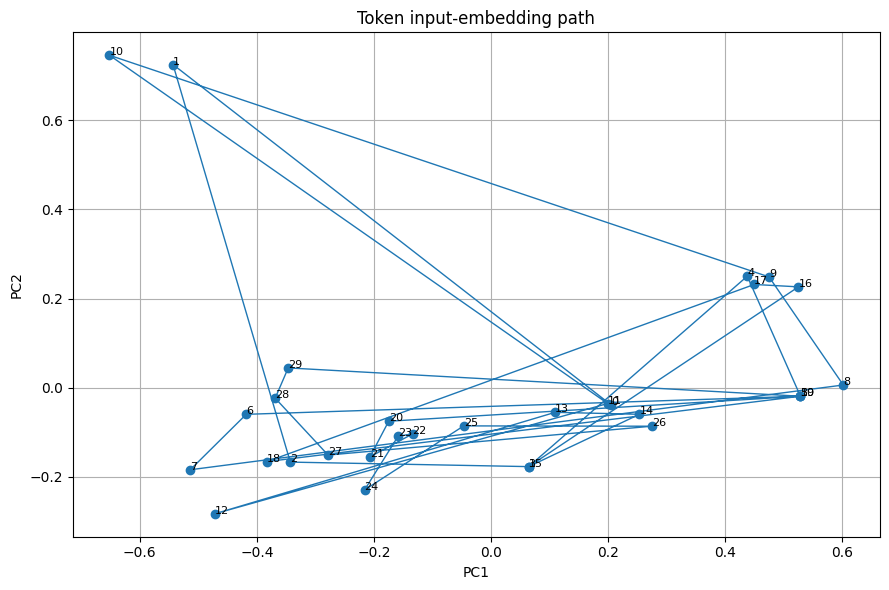

In [33]:
def token_embedding_path(text, max_length=160):
    if model is None or tokenizer is None:
        print("Model/tokenizer unavailable.")
        return pd.DataFrame()
    try:
        emb = get_input_embedding_layer()
        dev = embedding_device(emb)
        batch = tokenizer(text, return_tensors="pt", truncation=True, max_length=max_length).to(dev)
        with torch.inference_mode():
            token_emb = emb(batch["input_ids"])[0].float().cpu().numpy()
    except Exception as exc:
        print("Token embedding path failed:", repr(exc))
        return pd.DataFrame()

    ids = batch["input_ids"][0].detach().cpu().tolist()
    toks = tokenizer.convert_ids_to_tokens(ids)
    coords = pca_2d_embedding(token_emb)
    out = pd.DataFrame({"pos": range(len(ids)), "token_id": ids, "token": toks, "x": coords[:, 0], "y": coords[:, 1]})

    fig, axis = plt.subplots(figsize=(9, 6))
    axis.plot(out["x"], out["y"], marker="o", linewidth=1)
    for _, row in out.iloc[::max(1, len(out)//30)].iterrows():
        axis.annotate(str(row["pos"]), (row["x"], row["y"]), fontsize=8)
    axis.set_title("Token input-embedding path")
    axis.set_xlabel("PC1")
    axis.set_ylabel("PC2")
    plt.tight_layout()
    display(out.head(100))
    return out


def nearest_embedding_tokens(query, top_k=12, chunk_size=8192):
    if model is None or tokenizer is None:
        print("Model/tokenizer unavailable.")
        return pd.DataFrame()
    try:
        emb = get_input_embedding_layer(verbose=False)
        weight = emb.weight.detach()
        dev = weight.device
        ids = tokenizer(query, add_special_tokens=False, return_tensors="pt").input_ids[0].to(dev)
        if ids.numel() == 0:
            return pd.DataFrame()

        with torch.inference_mode():
            query_vec = weight.index_select(0, ids).float().mean(dim=0)
            query_vec = query_vec / query_vec.norm().clamp(min=1e-8)
            best_scores = []
            best_ids = []
            vocab_size = weight.shape[0]
            for start in range(0, vocab_size, chunk_size):
                chunk = weight[start:start + chunk_size].float()
                chunk = chunk / chunk.norm(dim=1, keepdim=True).clamp(min=1e-8)
                scores = chunk @ query_vec
                k = min(top_k, scores.numel())
                vals, idx = torch.topk(scores, k=k)
                best_scores.append(vals.cpu())
                best_ids.append((idx + start).cpu())
            scores = torch.cat(best_scores)
            token_ids = torch.cat(best_ids)
            vals, idx = torch.topk(scores, k=min(top_k, scores.numel()))
            token_ids = token_ids[idx].tolist()
            tokens = tokenizer.convert_ids_to_tokens(token_ids)
        return pd.DataFrame({"query": query, "rank": range(1, len(token_ids) + 1), "token_id": token_ids, "token": tokens, "cosine": vals.tolist()})
    except Exception as exc:
        print(f"Nearest embedding tokens failed for {query!r}:", repr(exc))
        return pd.DataFrame()


if RUN_EMBEDDING_PROBES and model is not None and tokenizer is not None and len(df):
    token_input_embedding_path_df = token_embedding_path(df.iloc[0]["prompt"])
    probe_terms = ["notebook", "change", "JSON", "double"]
    neighbor_tables = [nearest_embedding_tokens(term, top_k=10) for term in probe_terms]
    neighbor_tables = [table for table in neighbor_tables if len(table)]
    if neighbor_tables:
        neighbors = pd.concat(neighbor_tables, ignore_index=True)
        display(neighbors)
    else:
        print("No nearest-neighbor embedding tables were produced.")
else:
    print("Skipping token embedding path and nearest-neighbor probes.")


## Representation Probes

This section tries to extract hidden-state representations from the model. It may need adjustment for a different DLM repo because remote model code is not standardized.

What these plots can show:

- Do prompt variants cluster by family?
- Do completions cluster by schedule?
- Are failure cases separated from cleaner cases?
- Do answer-changing counterfactuals move in representation space?

What these plots do not prove:

- They do not prove the model performed faithful reasoning.
- They do not expose the full denoising trajectory unless the model returns it.
- PCA is only a view, not the latent space itself.


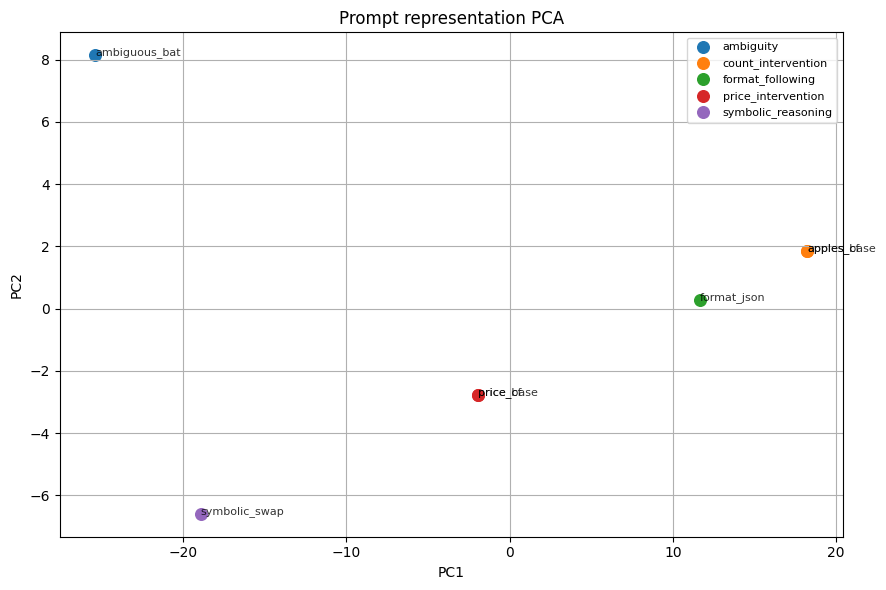

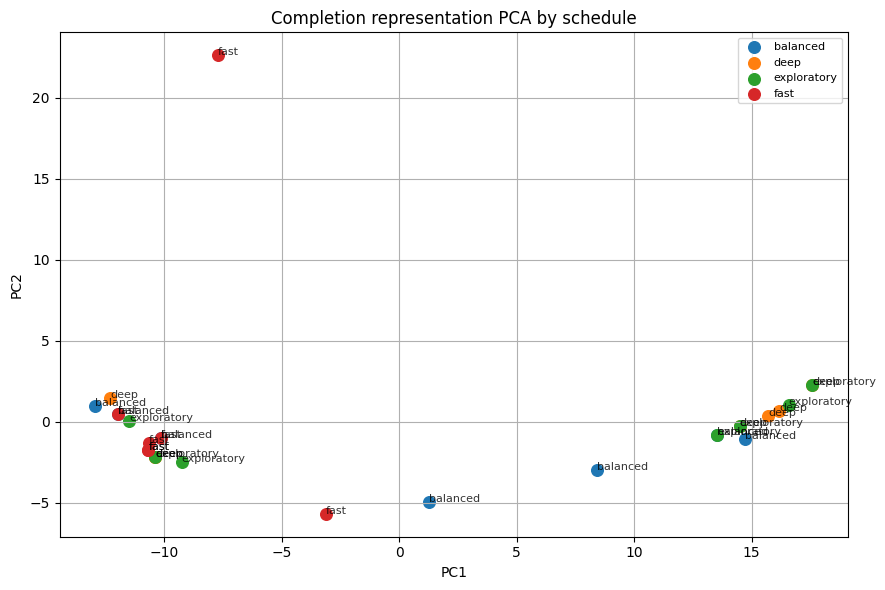

In [34]:
def pca_2d(x):
    x = np.asarray(x, dtype=np.float32)
    if x.ndim != 2 or len(x) == 0:
        return np.zeros((0, 2), dtype=np.float32)
    x = x - x.mean(axis=0, keepdims=True)
    u, s, vt = np.linalg.svd(x, full_matrices=False)
    if vt.shape[0] == 1:
        return np.column_stack([x @ vt[0], np.zeros(len(x))])
    return x @ vt[:2].T


def _get_hidden_states(batch):
    with torch.inference_mode():
        try:
            out = model(**batch, output_hidden_states=True, return_dict=True)
        except TypeError:
            out = model(input_ids=batch["input_ids"], attention_mask=batch.get("attention_mask"), output_hidden_states=True)
    hidden = getattr(out, "hidden_states", None)
    if hidden is None and isinstance(out, dict):
        hidden = out.get("hidden_states")
    if hidden is None:
        raise RuntimeError("Model forward did not return hidden_states.")
    return hidden


def text_representations(texts, layer=-1, max_length=256, pooling="mean"):
    if model is None or tokenizer is None:
        raise RuntimeError("Model/tokenizer are not loaded.")
    batch = tokenizer(list(texts), return_tensors="pt", padding=True, truncation=True, max_length=max_length).to(device)
    hidden = _get_hidden_states(batch)[layer]
    mask = batch.get("attention_mask")
    if pooling == "last":
        lengths = mask.sum(dim=1).clamp(min=1) - 1
        reps = hidden[torch.arange(hidden.shape[0], device=hidden.device), lengths]
    else:
        mask_f = mask.unsqueeze(-1).to(hidden.dtype)
        reps = (hidden * mask_f).sum(dim=1) / mask_f.sum(dim=1).clamp(min=1)
    return reps.float().cpu().numpy()


def plot_text_representations(df, text_col="prompt", label_col="family", layer=-1, title=None):
    if df.empty:
        print("No data.")
        return None
    try:
        reps = text_representations(df[text_col].astype(str).tolist(), layer=layer)
    except Exception as exc:
        print("Representation probe failed:", repr(exc))
        return None

    coords = pca_2d(reps)
    plot_df = df[["case_id", "name", "family", "variant", "category"]].copy()
    plot_df["x"] = coords[:, 0]
    plot_df["y"] = coords[:, 1]

    fig, axis = plt.subplots(figsize=(9, 6))
    for label, group in plot_df.groupby(label_col):
        axis.scatter(group["x"], group["y"], label=label, s=70)
        for _, row in group.iterrows():
            axis.annotate(row["case_id"] if text_col == "prompt" else row["name"], (row["x"], row["y"]), fontsize=8, alpha=0.8)
    axis.set_title(title or f"PCA of {text_col} representations, layer {layer}")
    axis.set_xlabel("PC1")
    axis.set_ylabel("PC2")
    axis.legend(fontsize=8)
    plt.tight_layout()
    return plot_df

if RUN_LATENT_PROBES and model is not None and tokenizer is not None and len(df):
    prompt_rep_df = plot_text_representations(df.drop_duplicates("case_id"), text_col="prompt", label_col="family", layer=-1, title="Prompt representation PCA")
    completion_rep_df = plot_text_representations(df, text_col="completion_clean", label_col="name", layer=-1, title="Completion representation PCA by schedule")
else:
    print("Skipping representation probes.")


## Token Path Probe

This plots a single text's token hidden states in PCA space and connects them in token order. It is useful for spotting abrupt representational jumps, but remember: this is token-position structure from a forward pass, not the diffusion denoising path.


,pos,token_id,token,x,y
0,0,32,A,-2.163674,21.548315
1,1,37166,Ġnotebook,-19.407995,-6.803591
2,2,7049,Ġcosts,-3.713130,19.901705
3,3,400,Ġ$,29.452524,8.197738
4,4,19,4,-43.924774,-34.860119
5,5,13,.,151.280075,20.218222
6,6,50344,ĠMaya,42.173573,11.316345
7,7,49531,Ġbuys,-20.663681,7.749532
8,8,220,Ġ,21.224815,-102.842270
9,9,18,3,-30.318420,38.360737


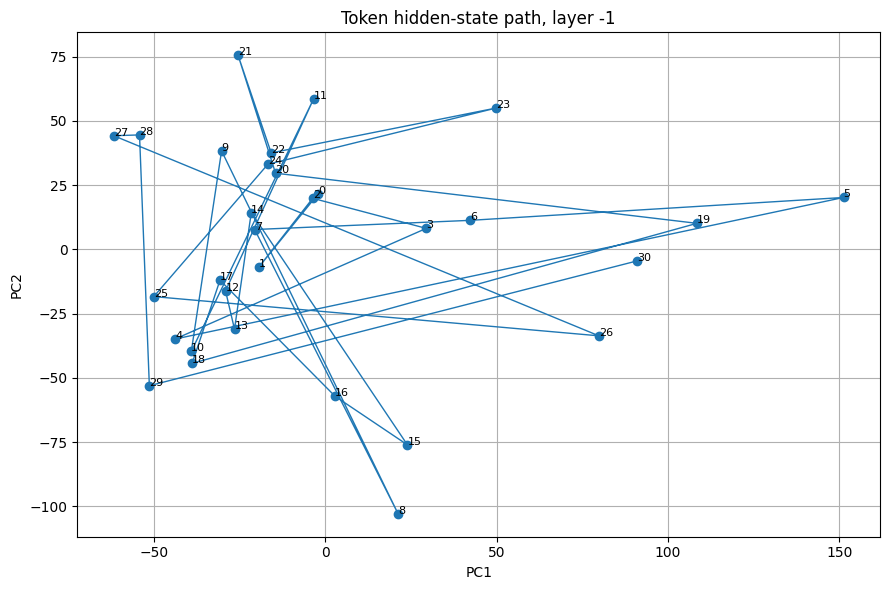

In [35]:
def _normalize_token_hidden_tensor(hidden_tensor, expected_len=None):
    """Return a [seq, dim] numpy array from model-specific hidden-state shapes."""
    h = hidden_tensor.detach().float().cpu()

    # Common shapes: [batch, seq, dim] or [seq, batch, dim].
    if h.ndim == 3:
        if h.shape[0] == 1:
            h = h[0]
        elif h.shape[1] == 1:
            h = h[:, 0, :]
        elif expected_len is not None and h.shape[0] == expected_len:
            h = h[:, 0, :]
        elif expected_len is not None and h.shape[1] == expected_len:
            h = h[0]
        else:
            h = h.reshape(-1, h.shape[-1])
    elif h.ndim > 3:
        h = h.reshape(-1, h.shape[-1])

    if h.ndim != 2:
        raise ValueError(f"Expected normalized hidden states to be 2D [seq, dim], got shape {tuple(h.shape)}")
    return h.numpy()


def token_path_probe(text, layer=-1, max_length=160):
    if model is None or tokenizer is None:
        print("Model/tokenizer unavailable.")
        return pd.DataFrame()

    input_device = get_model_input_device() if "get_model_input_device" in globals() else device
    batch = tokenizer(text, return_tensors="pt", truncation=True, max_length=max_length).to(input_device)
    ids = batch["input_ids"][0].detach().cpu().tolist()
    toks = tokenizer.convert_ids_to_tokens(ids)

    try:
        hidden_tensor = _get_hidden_states(batch)[layer]
        hidden = _normalize_token_hidden_tensor(hidden_tensor, expected_len=len(ids))
    except Exception as exc:
        print("Token path probe failed:", repr(exc))
        return pd.DataFrame()

    coords = pca_2d(hidden)
    n = min(len(ids), len(toks), coords.shape[0])
    if n == 0:
        print("Token path probe produced no aligned tokens.")
        return pd.DataFrame()
    if n != len(ids) or n != coords.shape[0]:
        print(
            "Token/hidden length mismatch; truncating for visualization:",
            {"tokens": len(ids), "hidden_positions": int(coords.shape[0]), "used": int(n)},
        )

    out = pd.DataFrame({
        "pos": range(n),
        "token_id": ids[:n],
        "token": toks[:n],
        "x": coords[:n, 0],
        "y": coords[:n, 1],
    })

    fig, axis = plt.subplots(figsize=(9, 6))
    axis.plot(out["x"], out["y"], marker="o", linewidth=1)
    for _, row in out.iloc[::max(1, len(out)//25)].iterrows():
        axis.annotate(str(row["pos"]), (row["x"], row["y"]), fontsize=8)
    axis.set_title(f"Token hidden-state path, layer {layer}")
    axis.set_xlabel("PC1")
    axis.set_ylabel("PC2")
    plt.tight_layout()
    display(out.head(80))
    return out

if RUN_LATENT_PROBES and model is not None and tokenizer is not None and len(df):
    token_path_df = token_path_probe(df.iloc[0]["prompt"], layer=-1)
else:
    print("Skipping token path probe.")


## High-Dimensional 3D Views

These plots project high-dimensional vectors into 3D with PCA. They are useful for quick geometric inspection, not proof of a mechanism.

What you can inspect:

- prompt clusters in input-embedding space
- completion clusters by schedule
- optional hidden-state clusters when `RUN_LATENT_PROBES=True`
- whether failures separate spatially from cleaner generations

The axes are principal components, not native model dimensions. Use the explained-variance values as a rough check for how much structure the 3D view preserves.


3D PCA explained variance: {'pc1': 0.3563055098056793, 'pc2': 0.2687973380088806, 'pc3': 0.18875744938850403}
3D PCA explained variance: {'pc1': 0.3518706262111664, 'pc2': 0.1504412591457367, 'pc3': 0.14480376243591309}
3D PCA explained variance: {'pc1': 0.9305867552757263, 'pc2': 0.06799904257059097, 'pc3': 0.0013012400595471263}
3D PCA explained variance: {'pc1': 0.7977195978164673, 'pc2': 0.1178847998380661, 'pc3': 0.03723256289958954}


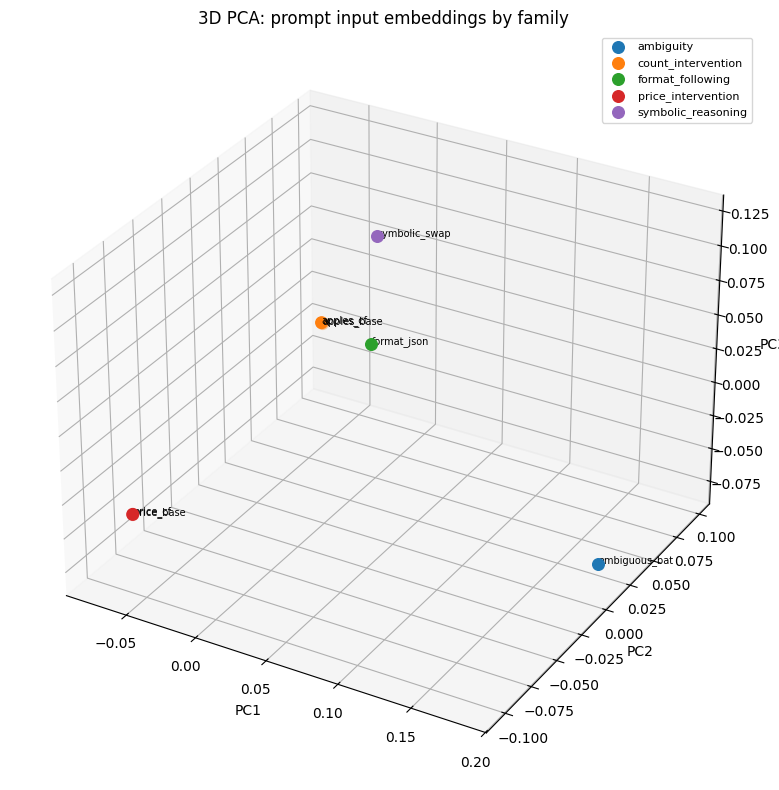

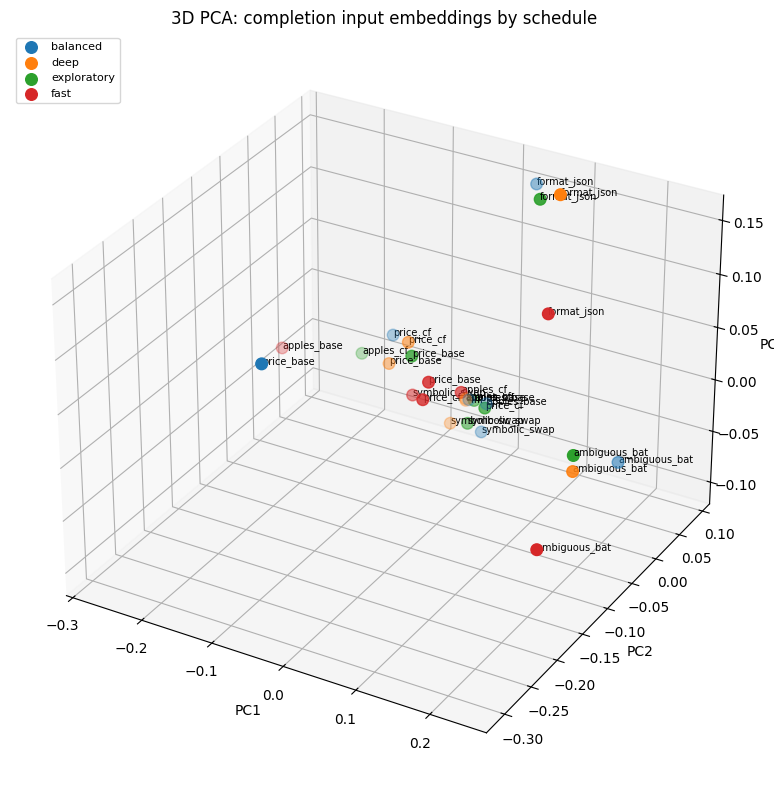

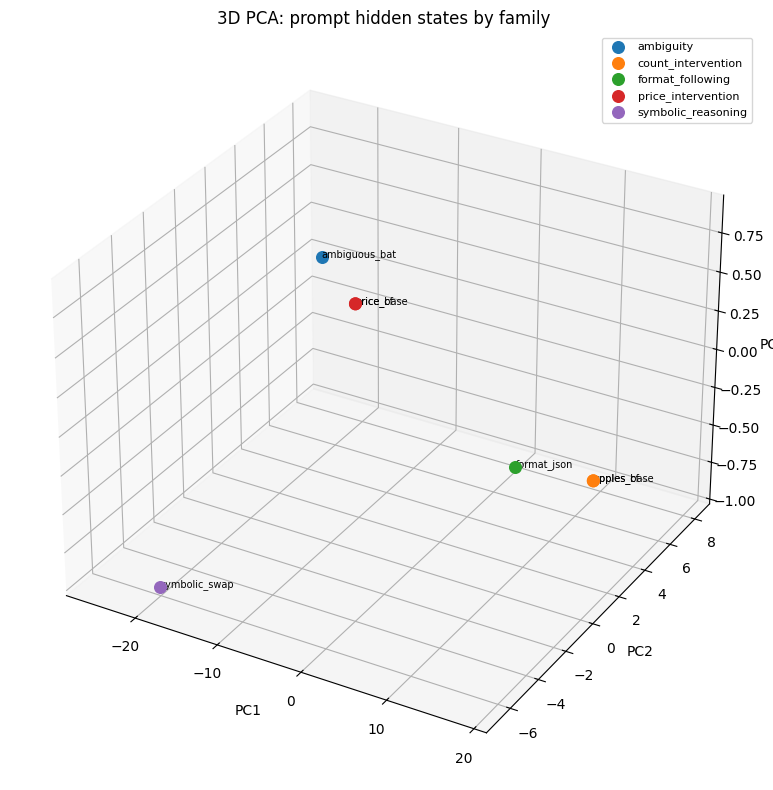

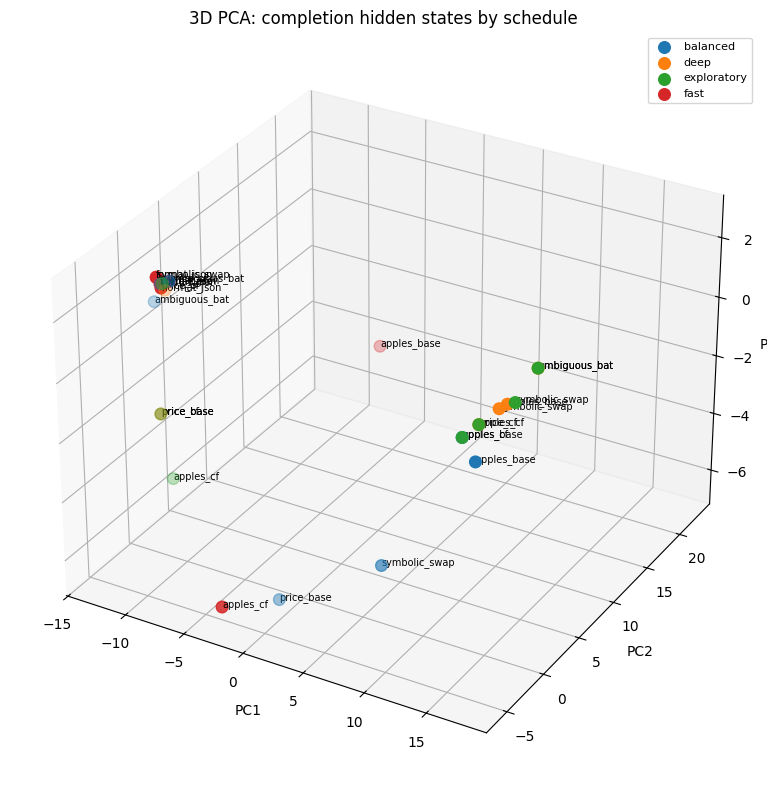

In [36]:
def pca_3d(x):
    x = np.asarray(x, dtype=np.float32)
    if x.ndim != 2 or len(x) == 0:
        return np.zeros((0, 3), dtype=np.float32), np.zeros(3, dtype=np.float32)
    x = x - x.mean(axis=0, keepdims=True)
    u, s, vt = np.linalg.svd(x, full_matrices=False)
    dims = min(3, vt.shape[0])
    coords = np.zeros((x.shape[0], 3), dtype=np.float32)
    coords[:, :dims] = x @ vt[:dims].T
    denom = float((s ** 2).sum()) if len(s) else 0.0
    explained = np.zeros(3, dtype=np.float32)
    if denom > 0:
        explained[:dims] = (s[:dims] ** 2) / denom
    return coords, explained


def plot_3d_projection(plot_df, title, label_col="name", annotate_col="case_id"):
    if plot_df.empty:
        print("No 3D projection data to plot.")
        return
    fig = plt.figure(figsize=(10, 8))
    axis = fig.add_subplot(111, projection="3d")
    for label, group in plot_df.groupby(label_col):
        axis.scatter(group["pc1"], group["pc2"], group["pc3"], label=label, s=70, depthshade=True)
        for _, row in group.iterrows():
            text = str(row.get(annotate_col, ""))
            if text:
                axis.text(row["pc1"], row["pc2"], row["pc3"], text, fontsize=7)
    axis.set_title(title)
    axis.set_xlabel("PC1")
    axis.set_ylabel("PC2")
    axis.set_zlabel("PC3")
    axis.legend(fontsize=8)
    plt.tight_layout()


def build_3d_text_projection(df, reps, label_col="name", annotate_col="case_id"):
    coords, explained = pca_3d(reps)
    out = df[["case_id", "family", "variant", "category", "name"]].copy()
    out["pc1"] = coords[:, 0]
    out["pc2"] = coords[:, 1]
    out["pc3"] = coords[:, 2]
    out["label"] = out[label_col] if label_col in out else "all"
    print("3D PCA explained variance:", {"pc1": float(explained[0]), "pc2": float(explained[1]), "pc3": float(explained[2])})
    return out


def plot_text_space_3d(df, text_col="prompt", representation="input_embedding", label_col="family", title=None):
    if df.empty:
        print("No generation rows for 3D projection.")
        return pd.DataFrame()
    try:
        if representation == "input_embedding":
            reps = text_input_embedding_representations(df[text_col].astype(str).tolist())
        elif representation == "hidden":
            reps = text_representations(df[text_col].astype(str).tolist(), layer=-1)
        else:
            raise ValueError(f"Unknown representation: {representation}")
    except Exception as exc:
        print(f"3D {representation} projection failed:", repr(exc))
        return pd.DataFrame()

    plot_df = build_3d_text_projection(df, reps, label_col=label_col)
    plot_3d_projection(
        plot_df,
        title or f"3D PCA of {text_col} using {representation}",
        label_col=label_col,
        annotate_col="case_id",
    )
    return plot_df


if len(df) and model is not None and tokenizer is not None:
    if RUN_EMBEDDING_PROBES and "text_input_embedding_representations" in globals():
        prompt_input_emb_3d_df = plot_text_space_3d(
            df.drop_duplicates("case_id"),
            text_col="prompt",
            representation="input_embedding",
            label_col="family",
            title="3D PCA: prompt input embeddings by family",
        )
        completion_input_emb_3d_df = plot_text_space_3d(
            df,
            text_col="completion_clean",
            representation="input_embedding",
            label_col="name",
            title="3D PCA: completion input embeddings by schedule",
        )
    else:
        print("Skipping 3D input-embedding projection.")

    if RUN_LATENT_PROBES and "text_representations" in globals():
        prompt_hidden_3d_df = plot_text_space_3d(
            df.drop_duplicates("case_id"),
            text_col="prompt",
            representation="hidden",
            label_col="family",
            title="3D PCA: prompt hidden states by family",
        )
        completion_hidden_3d_df = plot_text_space_3d(
            df,
            text_col="completion_clean",
            representation="hidden",
            label_col="name",
            title="3D PCA: completion hidden states by schedule",
        )
    else:
        print("Skipping 3D hidden-state projection.")
else:
    print("Skipping high-dimensional 3D views; no real rows or model/tokenizer unavailable.")


## Per-Prompt Hidden-State Trajectories In 3D

This view plots each prompt as a token-position trajectory through hidden-state space. For a prompt with tokens `t0, t1, ...`, the cell extracts one layer's hidden states, projects those token vectors into 3D with PCA, and connects them in token order.

This is useful for inspecting whether a prompt has abrupt representational jumps, whether related prompts take similar paths, and whether counterfactual edits bend the path around the edited token region.

Caveats:

- This is a forward-pass hidden-state path over token positions, not the DLM denoising-time trajectory.
- The 3D axes are PCA components fitted per prompt by default, so compare shapes cautiously.
- Set `PROMPT_TRAJECTORY_CASE_IDS` to a short list if plotting every prompt gets noisy.


price_base | price_intervention | base | layer -1
3D trajectory explained variance: {'pc1': 0.18136928975582123, 'pc2': 0.12218315154314041, 'pc3': 0.10422606766223907}


,pos,token_id,token,pc1,pc2,pc3
0,0,32,A,-2.163674,21.548315,-56.411983
1,1,37166,Ġnotebook,-19.407995,-6.803591,-56.523697
2,2,7049,Ġcosts,-3.713130,19.901705,-2.082791
3,3,400,Ġ$,29.452524,8.197738,8.183368
4,4,19,4,-43.924774,-34.860119,-25.586197
5,5,13,.,151.280075,20.218222,-36.181313
6,6,50344,ĠMaya,42.173573,11.316345,-58.310242
7,7,49531,Ġbuys,-20.663681,7.749532,-1.979186
8,8,220,Ġ,21.224815,-102.842270,9.403350
9,9,18,3,-30.318420,38.360737,-25.871780


price_cf | price_intervention | counterfactual | layer -1
3D trajectory explained variance: {'pc1': 0.17726920545101166, 'pc2': 0.12213259935379028, 'pc3': 0.10584823787212372}


,pos,token_id,token,pc1,pc2,pc3
0,0,32,A,-0.988825,25.523188,-59.671421
1,1,37166,Ġnotebook,-18.353094,-8.462854,-58.408871
2,2,7049,Ġcosts,-2.142259,20.398500,-0.008774
3,3,400,Ġ$,28.767467,9.370970,6.869665
4,4,20,5,-41.617294,-40.334152,-24.788607
5,5,13,.,149.750565,18.476662,-36.478748
6,6,50344,ĠMaya,40.565788,10.359596,-57.751480
7,7,49531,Ġbuys,-18.841406,7.438642,-2.763045
8,8,220,Ġ,22.061028,-96.938438,8.804024
9,9,18,3,-30.612400,38.405968,-28.075218


apples_base | count_intervention | base | layer -1
3D trajectory explained variance: {'pc1': 0.23093336820602417, 'pc2': 0.12255172431468964, 'pc3': 0.09801982343196869}


...

,pos,token_id,token,pc1,pc2,pc3
0,0,5598,Return,-72.590240,-1.962099,31.513023
1,1,1172,Ġonly,-24.829590,-72.901581,-10.566314
2,2,2697,Ġvalid,-42.483711,-87.319984,-15.536896
3,3,4718,ĠJSON,-103.799179,7.648890,-43.130623
4,4,448,Ġwith,-41.433121,-64.145493,2.375770
5,5,6894,Ġkeys,-26.695526,-62.114513,-6.800431
6,6,4226,Ġanswer,-125.490112,52.230614,-59.996536
7,7,323,Ġand,-10.857269,-72.017090,-11.451968
8,8,2874,Ġreason,-95.670532,53.462883,-39.380936
9,9,13,.,-45.241425,-7.191078,-13.679514


ambiguous_bat | ambiguity | base | layer -1
3D trajectory explained variance: {'pc1': 0.2261315882205963, 'pc2': 0.22294805943965912, 'pc3': 0.10323488712310791}


,pos,token_id,token,pc1,pc2,pc3
0,0,840,Ex,-137.215195,-102.022331,18.714750
1,1,20772,plain,29.744934,18.798281,-20.029324
2,2,1128,Ġwhat,58.875351,25.320810,-4.724536
3,3,264,Ġa,-86.376678,27.034546,105.257645
4,4,15743,Ġbat,-45.771866,-54.878540,11.918070
5,5,374,Ġis,-0.290509,-54.651207,-31.492115
6,6,304,Ġin,34.599701,17.986223,7.869062
7,7,825,Ġone,42.915817,-2.495876,38.837860
8,8,11652,Ġsentence,-27.366590,-41.543266,-60.644066
9,9,13,.,-69.178741,131.522034,-29.746742


symbolic_swap | symbolic_reasoning | base | layer -1
3D trajectory explained variance: {'pc1': 0.20041285455226898, 'pc2': 0.18084880709648132, 'pc3': 0.10260084271430969}


,pos,token_id,token,pc1,pc2,pc3
0,0,10061,Let,-62.790489,6.659741,-28.073576
1,1,362,ĠA,72.836929,27.582073,33.459206
2,2,3076,Ġmean,-42.572048,-79.068977,41.293419
3,3,1990,Ġdouble,27.603058,-30.533892,-10.551449
4,4,323,Ġand,-34.260506,-28.067616,-3.296629
5,5,425,ĠB,80.557556,28.633886,52.736107
6,6,3076,Ġmean,-29.708027,-58.942886,59.757370
7,7,912,Ġadd,25.908033,-43.385422,-15.362424
8,8,2326,Ġthree,47.986671,-12.297009,3.488436
9,9,13,.,-9.717943,62.482513,78.415741


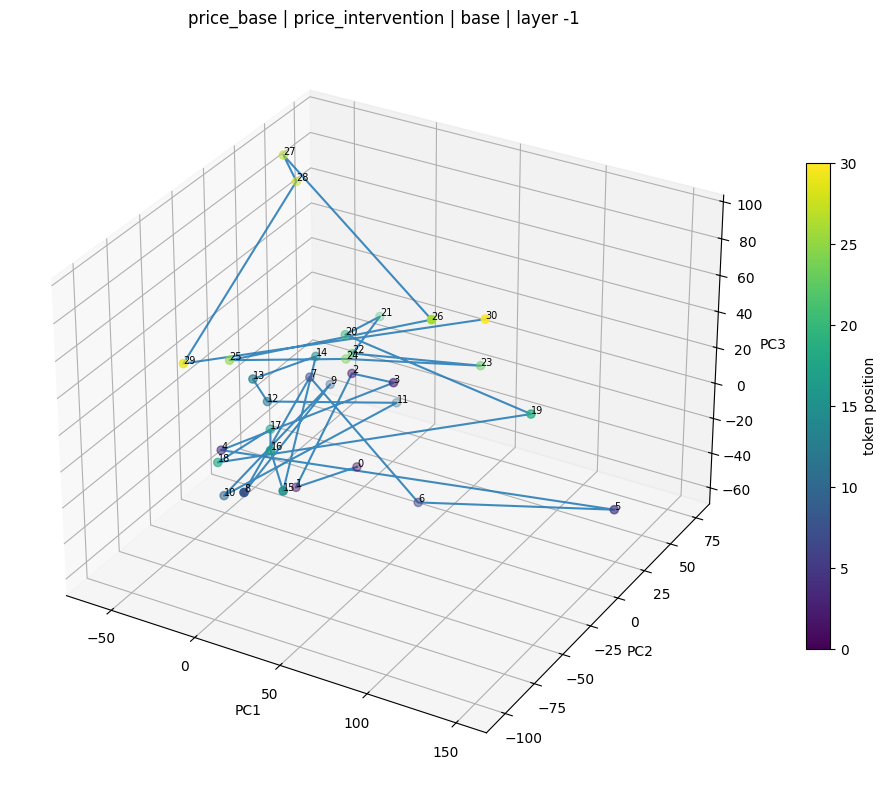

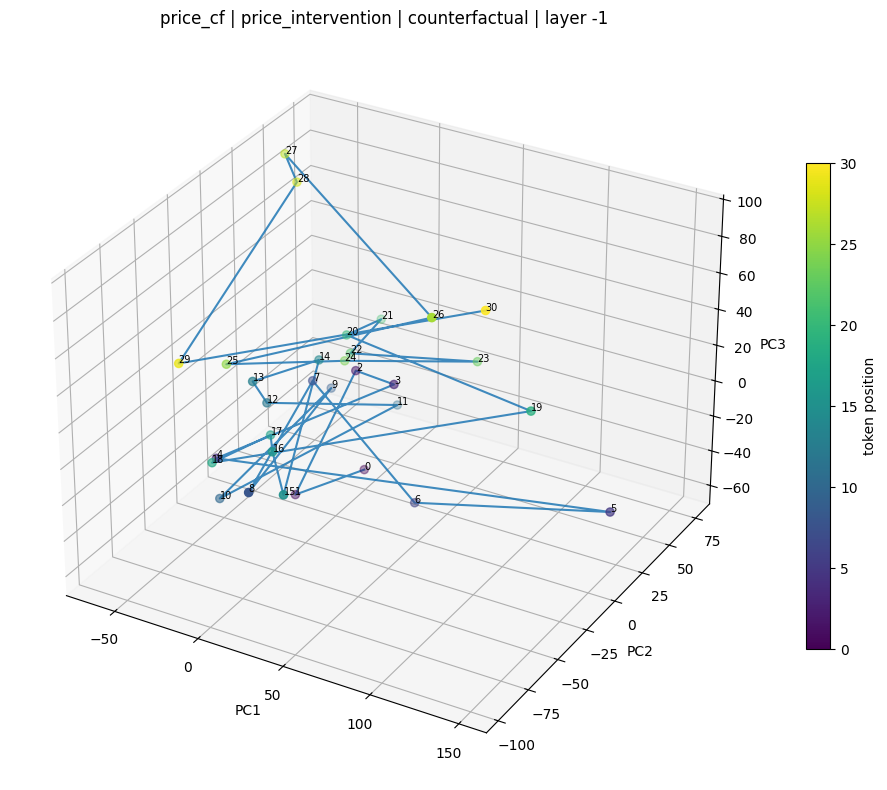

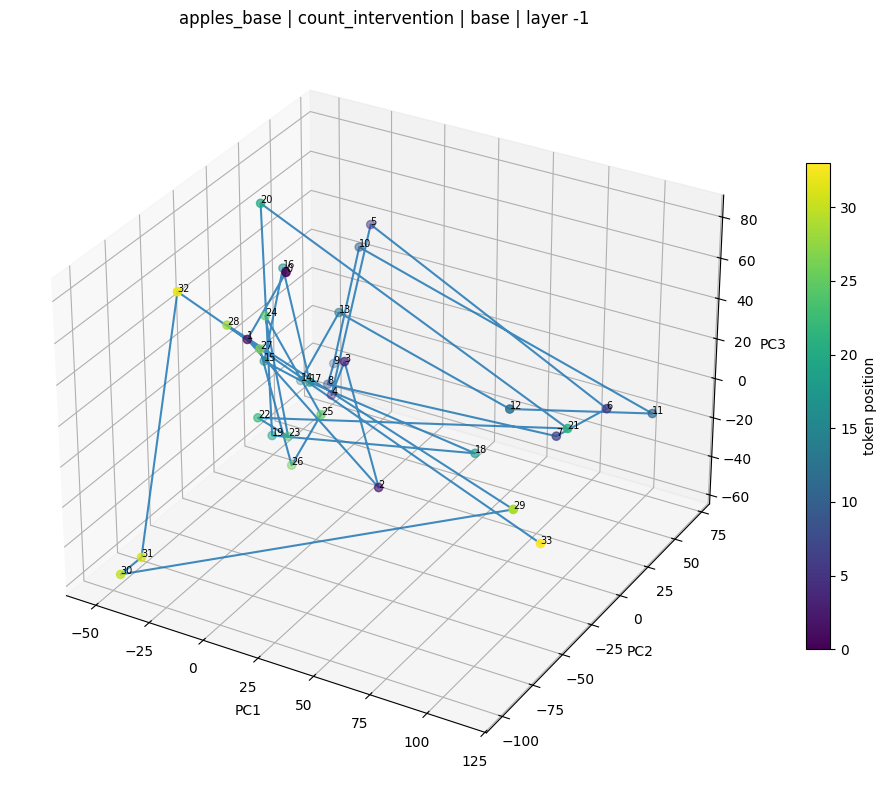

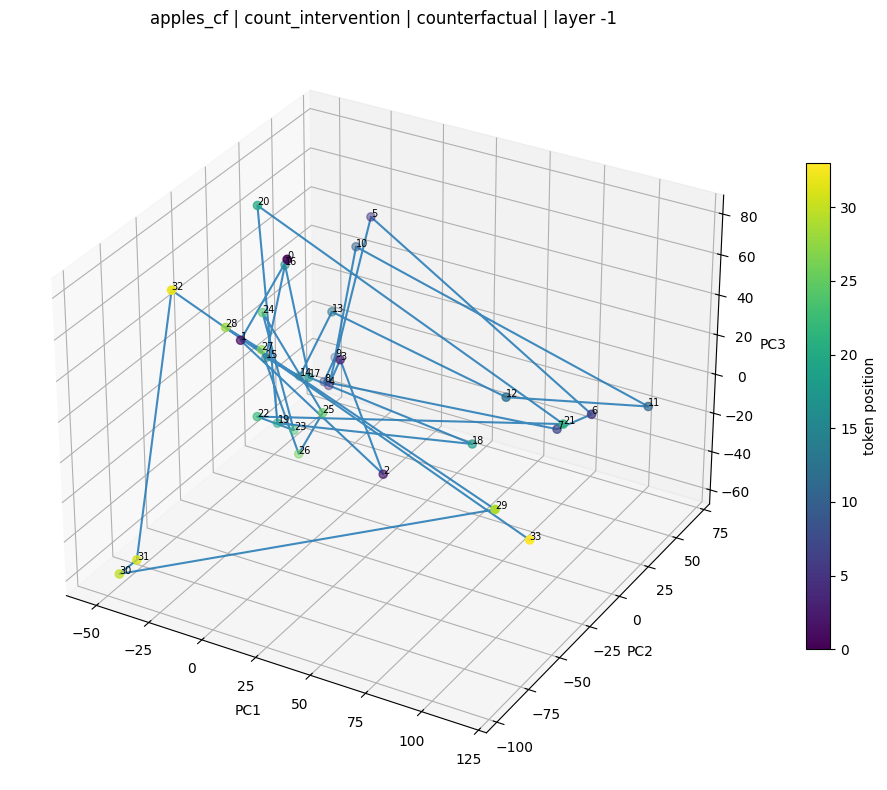

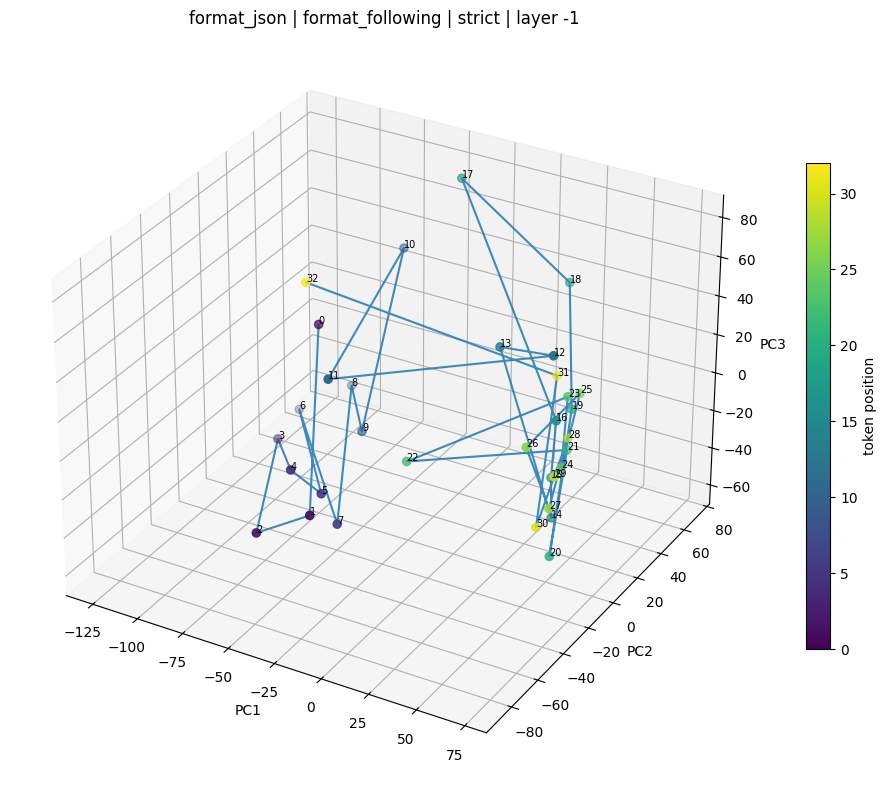

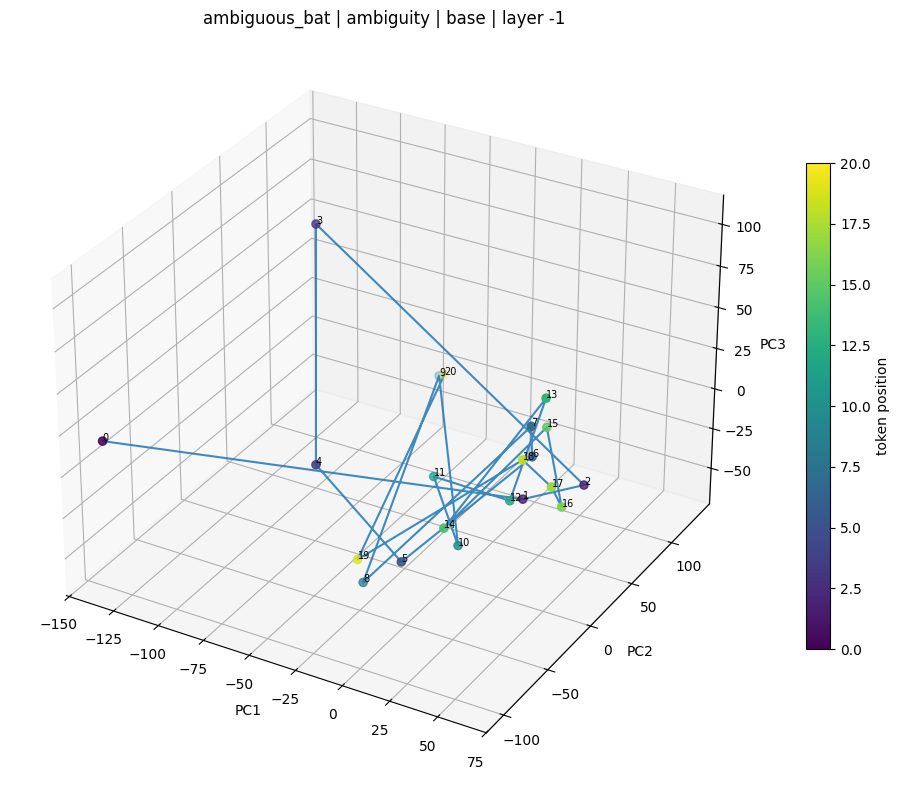

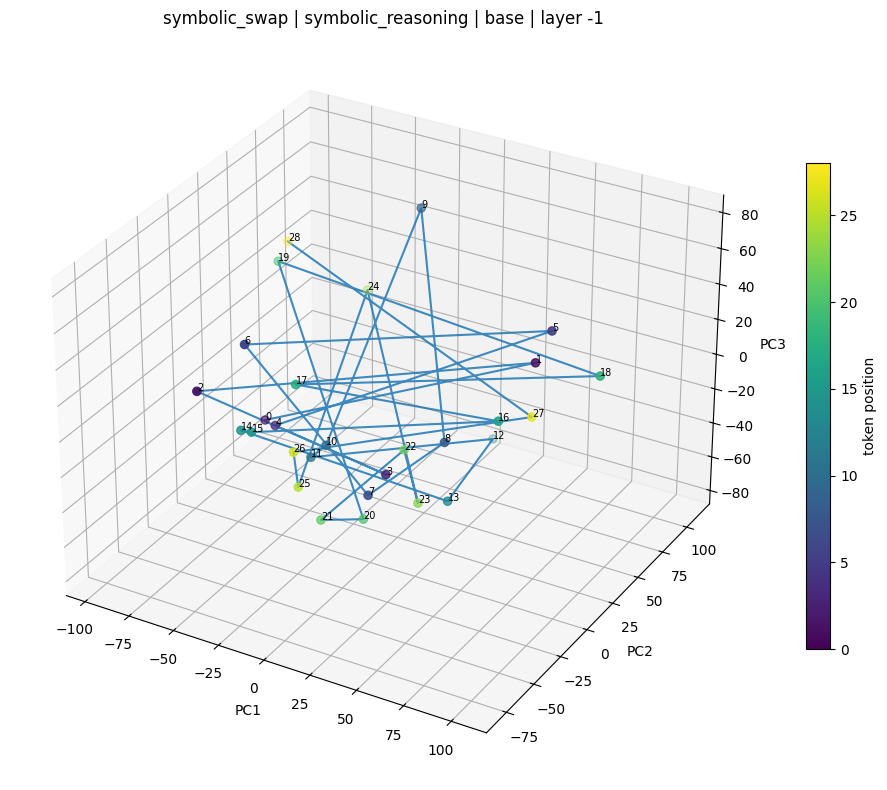

In [37]:
PROMPT_TRAJECTORY_CASE_IDS = None  # Example: ["price_base", "price_cf"]
PROMPT_TRAJECTORY_LAYER = -1
PROMPT_TRAJECTORY_MAX_PROMPTS = 12
PROMPT_TRAJECTORY_MAX_LENGTH = 192


def hidden_state_token_trajectory_3d(text, layer=-1, max_length=192, title=None, annotate_every=None):
    if model is None or tokenizer is None:
        print("Model/tokenizer unavailable.")
        return pd.DataFrame()

    input_device = get_model_input_device() if "get_model_input_device" in globals() else device
    batch = tokenizer(text, return_tensors="pt", truncation=True, max_length=max_length).to(input_device)
    ids = batch["input_ids"][0].detach().cpu().tolist()
    toks = tokenizer.convert_ids_to_tokens(ids)

    try:
        hidden_tensor = _get_hidden_states(batch)[layer]
        hidden = _normalize_token_hidden_tensor(hidden_tensor, expected_len=len(ids))
    except Exception as exc:
        print("Hidden-state trajectory failed:", repr(exc))
        return pd.DataFrame()

    coords, explained = pca_3d(hidden)
    n = min(len(ids), len(toks), coords.shape[0])
    if n == 0:
        print("Hidden-state trajectory produced no aligned tokens.")
        return pd.DataFrame()
    if n != len(ids) or n != coords.shape[0]:
        print(
            "Token/hidden length mismatch; truncating trajectory:",
            {"tokens": len(ids), "hidden_positions": int(coords.shape[0]), "used": int(n)},
        )

    out = pd.DataFrame({
        "pos": range(n),
        "token_id": ids[:n],
        "token": toks[:n],
        "pc1": coords[:n, 0],
        "pc2": coords[:n, 1],
        "pc3": coords[:n, 2],
    })

    fig = plt.figure(figsize=(10, 8))
    axis = fig.add_subplot(111, projection="3d")
    axis.plot(out["pc1"], out["pc2"], out["pc3"], linewidth=1.5, alpha=0.85)
    points = axis.scatter(
        out["pc1"], out["pc2"], out["pc3"],
        c=out["pos"], cmap="viridis", s=35, depthshade=True,
    )

    if annotate_every is None:
        annotate_every = max(1, len(out) // 20)
    for _, row in out.iloc[::annotate_every].iterrows():
        axis.text(row["pc1"], row["pc2"], row["pc3"], str(row["pos"]), fontsize=7)

    axis.set_title(title or f"Prompt hidden-state trajectory, layer {layer}")
    axis.set_xlabel("PC1")
    axis.set_ylabel("PC2")
    axis.set_zlabel("PC3")
    fig.colorbar(points, ax=axis, shrink=0.65, label="token position")
    plt.tight_layout()
    print("3D trajectory explained variance:", {"pc1": float(explained[0]), "pc2": float(explained[1]), "pc3": float(explained[2])})
    display(out.head(120))
    return out


def plot_each_prompt_hidden_trajectory_3d(
    df,
    case_ids=None,
    layer=-1,
    max_prompts=12,
    max_length=192,
):
    if df.empty:
        print("No generation rows for prompt trajectory plots.")
        return {}
    prompt_df = df.drop_duplicates("case_id")[["case_id", "family", "variant", "category", "prompt"]].copy()
    if case_ids is not None:
        wanted = set(case_ids)
        prompt_df = prompt_df[prompt_df["case_id"].isin(wanted)]
    prompt_df = prompt_df.head(max_prompts)

    trajectories = {}
    for _, row in prompt_df.iterrows():
        title = f"{row['case_id']} | {row['family']} | {row['variant']} | layer {layer}"
        print("=" * 100)
        print(title)
        trajectories[row["case_id"]] = hidden_state_token_trajectory_3d(
            row["prompt"],
            layer=layer,
            max_length=max_length,
            title=title,
        )
    return trajectories


if RUN_LATENT_PROBES and model is not None and tokenizer is not None and len(df):
    prompt_hidden_trajectory_3d = plot_each_prompt_hidden_trajectory_3d(
        df,
        case_ids=PROMPT_TRAJECTORY_CASE_IDS,
        layer=PROMPT_TRAJECTORY_LAYER,
        max_prompts=PROMPT_TRAJECTORY_MAX_PROMPTS,
        max_length=PROMPT_TRAJECTORY_MAX_LENGTH,
    )
else:
    print("Skipping per-prompt hidden-state trajectories; enable RUN_LATENT_PROBES with a loaded model and real rows.")


## Optional: Generation Trace Hooks

Some model repos expose intermediate denoising states, logits, confidence, or per-step token changes. Efficient-DLM's public `generate` API may only return final ids and NFE.

If your model returns richer objects, adapt `generate_dlm` above to store them in `rows`. Good trace-level quantities to look for:

- number of tokens changed per denoising step
- per-step entropy or max probability
- first step where the final answer token stabilizes
- positions that keep flipping late in generation
- whether counterfactual variables affect the same positions across schedules

Trace-level data is much closer to the real DLM mechanism than text-only scoring.


In [38]:
# Placeholder for model-specific tracing.
# Example fields to add if your model generate() supports them:
# row["trace_token_change_rate"] = [...]
# row["trace_entropy"] = [...]
# row["trace_answer_position_stabilized_at"] = int_or_none
# row["trace_intermediate_text"] = [text_step_0, text_step_1, ...]

print("Trace hook placeholder. Inspect your model's remote generate() implementation for supported return fields.")


Trace hook placeholder. Inspect your model's remote generate() implementation for supported return fields.


## Export Results

The CSV is convenient for quick analysis. JSONL preserves list-like fields such as `anchor_terms` more naturally.


In [39]:
if SAVE_RESULTS and len(df):
    stamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    csv_path = RUN_DIR / f"dlm_behavior_{stamp}.csv"
    jsonl_path = RUN_DIR / f"dlm_behavior_{stamp}.jsonl"
    df.to_csv(csv_path, index=False)
    with jsonl_path.open("w") as f:
        for row in df.to_dict(orient="records"):
            f.write(json.dumps(row, default=str) + "\n")
    print("saved:", csv_path)
    print("saved:", jsonl_path)
else:
    print("Nothing saved.")


saved: dlm_runs/dlm_behavior_20260522_181120.csv
saved: dlm_runs/dlm_behavior_20260522_181120.jsonl


/tmp/ipykernel_1072/747847566.py:7: UserWarning: DataFrame columns are not unique, some columns will be omitted.
  for row in df.to_dict(orient="records"):


## Where To Extend This Notebook

Good next additions:

1. Add a larger prompt suite with tags for skill, difficulty, ambiguity, and expected invariances.
2. Add repeated seeds per schedule to separate stable behavior from one-off runs.
3. Add exact parsers for JSON, math answers, code blocks, or theorem-proof structure.
4. Patch the model's remote `generate` method to return intermediate denoising states.
5. Compare hidden-state probes across layers, not just the final layer.
6. Cluster failure cases and then read the raw outputs for each cluster.
7. Add activation patching or logit-lens style probes if the model architecture exposes compatible internals.

The strongest workflow is: run broad sweeps, find weird clusters, inspect raw text, then build a smaller targeted mechanistic probe around the behavior you actually observe.
